# Phase 8 — Tổng Hợp Kết Quả & Trực Quan Hóa Đa Chiều (Final Synthesis & Visualization)

Dự án: **An Evolving Fuzzy Reasoning System for Sensor Stream Anomaly Detection under Concept Drift**

## Phase 8.0 — Thiết lập Môi trường (Setup)

In [1]:
# PHASE 8.0 — SETUP
print("=== PHASE 8.0 — SETUP ===")

import pandas as pd
from IPython.display import display

print("pandas version:", pd.__version__)
print("Phase 8 setup: PASS")


=== PHASE 8.0 — SETUP ===
pandas version: 3.0.6
Phase 8 setup: PASS


## Phase 8.1a — Chuẩn Hóa Điểm Chuẩn Đối Chứng Control (Normalize Control Reference)

Control đóng vai trò kịch bản đối chuẩn tham chiếu (reference scenario) cho hệ mờ tĩnh Static FIS trên Test stream nguyên bản (không tiêm trôi dạt). Các giá trị ma trận nhầm lẫn được kế thừa trực tiếp từ kết quả đã đóng băng ở Phase 3: TP = 13, TN = 1927, FP = 34, FN = 26 trên 2.000 mẫu.

In [2]:
# PHASE 8.1a — NORMALIZE CONTROL REFERENCE

print("=== PHASE 8.1a — NORMALIZE CONTROL REFERENCE ===")


# ---------------------------------------------------------
# Control = Original Test Stream, No Injected Drift
# ---------------------------------------------------------

control_tp = 13
control_tn = 1927
control_fp = 34
control_fn = 26

control_total = (
    control_tp
    + control_tn
    + control_fp
    + control_fn
)


# ---------------------------------------------------------
# Metrics
# ---------------------------------------------------------

control_precision = (
    control_tp / (control_tp + control_fp)
    if (control_tp + control_fp) > 0
    else 0.0
)

control_recall = (
    control_tp / (control_tp + control_fn)
    if (control_tp + control_fn) > 0
    else 0.0
)

control_f1 = (
    2 * control_precision * control_recall
    / (control_precision + control_recall)
    if (control_precision + control_recall) > 0
    else 0.0
)

control_fpr = (
    control_fp / (control_fp + control_tn)
    if (control_fp + control_tn) > 0
    else 0.0
)

control_fnr = (
    control_fn / (control_fn + control_tp)
    if (control_fn + control_tp) > 0
    else 0.0
)

control_specificity = (
    control_tn / (control_tn + control_fp)
    if (control_tn + control_fp) > 0
    else 0.0
)

control_balanced_accuracy = (
    control_recall + control_specificity
) / 2


# ---------------------------------------------------------
# Validation against known Phase 3 results
# ---------------------------------------------------------

assert control_total == 2000

assert control_tp == 13
assert control_tn == 1927
assert control_fp == 34
assert control_fn == 26

assert 0.0 <= control_precision <= 1.0
assert 0.0 <= control_recall <= 1.0
assert 0.0 <= control_f1 <= 1.0
assert 0.0 <= control_fpr <= 1.0
assert 0.0 <= control_fnr <= 1.0
assert 0.0 <= control_specificity <= 1.0
assert 0.0 <= control_balanced_accuracy <= 1.0


print("\n--- Control Reference ---")
print(f"Total samples       : {control_total}")
print(f"TP                  : {control_tp}")
print(f"TN                  : {control_tn}")
print(f"FP                  : {control_fp}")
print(f"FN                  : {control_fn}")
print(f"Precision           : {control_precision:.6f}")
print(f"Recall              : {control_recall:.6f}")
print(f"F1                  : {control_f1:.6f}")
print(f"FPR                 : {control_fpr:.6f}")
print(f"FNR                 : {control_fnr:.6f}")
print(f"Specificity         : {control_specificity:.6f}")
print(f"Balanced Accuracy   : {control_balanced_accuracy:.6f}")

print("\nControl confusion-matrix consistency: PASS")
print("Control metric range checks: PASS")
print("Control reference normalization: COMPLETE")


=== PHASE 8.1a — NORMALIZE CONTROL REFERENCE ===

--- Control Reference ---
Total samples       : 2000
TP                  : 13
TN                  : 1927
FP                  : 34
FN                  : 26
Precision           : 0.276596
Recall              : 0.333333
F1                  : 0.302326
FPR                 : 0.017338
FNR                 : 0.666667
Specificity         : 0.982662
Balanced Accuracy   : 0.657998

Control confusion-matrix consistency: PASS
Control metric range checks: PASS
Control reference normalization: COMPLETE


## Phase 8.1 — Bảng Tổng Hợp Kết Quả Thực Nghiệm Toàn Diện (Final Experiment Summary)

Gom toàn bộ kết quả của 3 kịch bản stream (Control, Sudden Drift, Gradual Drift) đối chiếu giữa Static FIS và Evolving FIS trên cùng quy mô 2.000 mẫu và cùng ngưỡng cố định TAU_STATIC = 0.67.

In [3]:
# PHASE 8.1 — FINAL EXPERIMENT SUMMARY
print("=== PHASE 8.1 — FINAL EXPERIMENT SUMMARY ===")

# ============================================================
# 1. CONTROL — REFERENCE RESULT FROM PHASE 3
# ============================================================

control_result = {
    "Scenario": "Control",
    "Model": "Static Fuzzy",
    "Samples": 2000,
    "TP": 13,
    "TN": 1927,
    "FP": 34,
    "FN": 26,
    "Precision": control_precision,
    "Recall": control_recall,
    "F1": control_f1,
    "FPR": control_fpr,
    "FNR": control_fnr,
    "Specificity": control_specificity,
    "Balanced Accuracy": control_balanced_accuracy,
}

# ============================================================
# 2. SUDDEN — FROZEN RESULTS FROM PHASE 7
# ============================================================

sudden_static_result = {
    "Scenario": "Sudden",
    "Model": "Static Fuzzy",
    "Samples": 2000,
    "TP": 18,
    "TN": 1847,
    "FP": 114,
    "FN": 21,
    "Precision": 0.136364,
    "Recall": 0.461538,
    "F1": 0.210526,
    "FPR": 0.058134,
    "FNR": 0.538462,
    "Specificity": 0.941866,
    "Balanced Accuracy": 0.701702,
}

sudden_evolving_result = {
    "Scenario": "Sudden",
    "Model": "Evolving Fuzzy",
    "Samples": 2000,
    "TP": 15,
    "TN": 1905,
    "FP": 56,
    "FN": 24,
    "Precision": 0.211268,
    "Recall": 0.384615,
    "F1": 0.272727,
    "FPR": 0.028557,
    "FNR": 0.615385,
    "Specificity": 0.971443,
    "Balanced Accuracy": 0.678029,
}

# ============================================================
# 3. GRADUAL — FROZEN RESULTS FROM PHASE 7
# ============================================================

gradual_static_result = {
    "Scenario": "Gradual",
    "Model": "Static Fuzzy",
    "Samples": 2000,
    "TP": 18,
    "TN": 1848,
    "FP": 113,
    "FN": 21,
    "Precision": 0.137405,
    "Recall": 0.461538,
    "F1": 0.211765,
    "FPR": 0.057624,
    "FNR": 0.538462,
    "Specificity": 0.942376,
    "Balanced Accuracy": 0.701957,
}

gradual_evolving_result = {
    "Scenario": "Gradual",
    "Model": "Evolving Fuzzy",
    "Samples": 2000,
    "TP": 14,
    "TN": 1900,
    "FP": 61,
    "FN": 25,
    "Precision": 0.186667,
    "Recall": 0.358974,
    "F1": 0.245614,
    "FPR": 0.031107,
    "FNR": 0.641026,
    "Specificity": 0.968893,
    "Balanced Accuracy": 0.663934,
}

# ============================================================
# 4. BUILD SUMMARY TABLE
# ============================================================

summary_results = [
    control_result,
    sudden_static_result,
    sudden_evolving_result,
    gradual_static_result,
    gradual_evolving_result,
]

summary_df = pd.DataFrame(summary_results)

metric_columns = [
    "Precision",
    "Recall",
    "F1",
    "FPR",
    "FNR",
    "Specificity",
    "Balanced Accuracy",
]

summary_display = summary_df.copy()

for col in metric_columns:
    summary_display[col] = summary_display[col].round(4)

print("\n--- Final Experiment Summary ---")
display(summary_display)

# ============================================================
# 5. INTEGRITY CHECKS
# ============================================================

assert len(summary_df) == 5

for _, row in summary_df.iterrows():
    confusion_total = row["TP"] + row["TN"] + row["FP"] + row["FN"]
    assert confusion_total == row["Samples"], (
        f"Confusion mismatch: {row['Scenario']} / {row['Model']}"
    )

    for metric in metric_columns:
        assert 0.0 <= row[metric] <= 1.0, (
            f"Metric out of range: {row['Scenario']} / "
            f"{row['Model']} / {metric}"
        )

assert summary_df["Samples"].eq(2000).all()

print("\nConfusion-matrix consistency: PASS")
print("Metric range checks: PASS")
print("Sample-count checks: PASS")
print("Final experiment summary: COMPLETE")


=== PHASE 8.1 — FINAL EXPERIMENT SUMMARY ===

--- Final Experiment Summary ---
  Scenario           Model  Samples  ...     FNR  Specificity  Balanced Accuracy
0  Control    Static Fuzzy     2000  ...  0.6667       0.9827             0.6580
1   Sudden    Static Fuzzy     2000  ...  0.5385       0.9419             0.7017
2   Sudden  Evolving Fuzzy     2000  ...  0.6154       0.9714             0.6780
3  Gradual    Static Fuzzy     2000  ...  0.5385       0.9424             0.7020
4  Gradual  Evolving Fuzzy     2000  ...  0.6410       0.9689             0.6639

[5 rows x 14 columns]

Confusion-matrix consistency: PASS
Metric range checks: PASS
Sample-count checks: PASS
Final experiment summary: COMPLETE


## Phase 8.2a — Kiểm Tra Tính Khả Dụng Của Dữ Liệu (Inspect Data Availability)

Kiểm tra sự hiện diện của các biến kết quả tóm tắt trong không gian biến của Phase 8 trước khi thiết kế các trực quan hóa.

In [4]:
# PHASE 8.2a — INSPECT DATA AVAILABILITY
print("=== PHASE 8.2a — INSPECT DATA AVAILABILITY ===")

print("Variables available in Phase 8:")

required_names = [
    "summary_df",
    "control_result",
    "sudden_static_result",
    "sudden_evolving_result",
    "gradual_static_result",
    "gradual_evolving_result",
]

for name in required_names:
    print(f"{name:30s}:", "FOUND" if name in globals() else "MISSING")

print("\nPhase 8.2a inspection: COMPLETE")


=== PHASE 8.2a — INSPECT DATA AVAILABILITY ===
Variables available in Phase 8:
summary_df                    : FOUND
control_result                : FOUND
sudden_static_result          : FOUND
sudden_evolving_result        : FOUND
gradual_static_result         : FOUND
gradual_evolving_result       : FOUND

Phase 8.2a inspection: COMPLETE


## Phase 8.2b — Kiểm Tra Dữ Liệu Luồng Cảm Biến Và Chuỗi Điểm Số (Inspect Score / Stream Data)

Khảo sát sự hiện diện của các mảng điểm bất thường và dữ liệu luồng cảm biến trong bộ nhớ của Phase 8 để quyết định phương án trực quan hóa thích hợp.

In [5]:
# PHASE 8.2b — INSPECT SCORE / STREAM DATA
print("=== PHASE 8.2b — INSPECT SCORE / STREAM DATA ===")

candidate_names = [
    "control_scores",
    "sudden_scores",
    "gradual_scores",
    "sudden_static_scores",
    "sudden_evolving_scores",
    "gradual_static_scores",
    "gradual_evolving_scores",
    "stream_df",
    "test_df",
]

for name in candidate_names:
    if name in globals():
        obj = globals()[name]

        try:
            print(
                f"{name:30s}: FOUND | "
                f"type={type(obj).__name__} | "
                f"length={len(obj)}"
            )
        except TypeError:
            print(
                f"{name:30s}: FOUND | "
                f"type={type(obj).__name__}"
            )
    else:
        print(f"{name:30s}: MISSING")

print("\nPhase 8.2b inspection: COMPLETE")


=== PHASE 8.2b — INSPECT SCORE / STREAM DATA ===
control_scores                : MISSING
sudden_scores                 : MISSING
gradual_scores                : MISSING
sudden_static_scores          : MISSING
sudden_evolving_scores        : MISSING
gradual_static_scores         : MISSING
gradual_evolving_scores       : MISSING
stream_df                     : MISSING
test_df                       : MISSING

Phase 8.2b inspection: COMPLETE


## Phase 8.2 — Nạp Bộ Dữ Liệu Gốc Phục Vụ Tái Tạo Luồng (Load Source Dataset)

Nạp lại tệp dữ liệu gốc `data/ai4i2020.csv` một cách độc lập trong notebook Phase 8 để chuẩn bị cho việc tái tạo các luồng kiểm thử.

In [6]:
# PHASE 8.2 — LOAD SOURCE DATASET
print("=== PHASE 8.2 — LOAD SOURCE DATASET ===")

from pathlib import Path
import numpy as np

DATA_PATH = Path("../data/ai4i2020.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("data/ai4i2020.csv")

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

df_phase8 = pd.read_csv(DATA_PATH)

print("Dataset path :", DATA_PATH.resolve())
print("Shape        :", df_phase8.shape)
print("Columns      :", len(df_phase8.columns))

assert df_phase8.shape == (10000, 14)

print("Dataset shape check: PASS")
print("Phase 8.2 dataset loading: COMPLETE")


=== PHASE 8.2 — LOAD SOURCE DATASET ===
Dataset path : E:\thacsy\hệ thống thông minh\An-Evolving-Fuzzy-Reasoning-System-for-Sensor-Stream-Anomaly-Detection-under-Concept-Drift\data\ai4i2020.csv
Shape        : (10000, 14)
Columns      : 14
Dataset shape check: PASS
Phase 8.2 dataset loading: COMPLETE


## Phase 8.3 — Tái Tạo Các Kịch Bản Luồng Dữ Liệu Kiểm Thử (Reconstruct Stream Scenarios)

Tái tạo chính xác 3 kịch bản luồng kiểm thử độc lập từ phân vùng Test (UDI 8001 → 10000, 2.000 mẫu) theo đúng thông số đã chốt ở Phase 4: Control (không can thiệp), Sudden Drift (bước nhảy tại index 1000) và Gradual Drift (chuyển tiếp tuyến tính qua index 800 → 1200).

In [7]:
# PHASE 8.3 — RECONSTRUCT STREAM SCENARIOS
print("=== PHASE 8.3 — RECONSTRUCT STREAM SCENARIOS ===")

import numpy as np

# ---------------------------------------------------------
# 1. Base stream = original Test set
# ---------------------------------------------------------
stream_df = df_phase8.iloc[8000:].copy().reset_index(drop=True)

assert len(stream_df) == 2000
assert stream_df["UDI"].iloc[0] == 8001
assert stream_df["UDI"].iloc[-1] == 10000

# ---------------------------------------------------------
# 2. Control scenario
# ---------------------------------------------------------
control_stream = stream_df.copy()

# ---------------------------------------------------------
# 3. Drift parameters — identical to Phase 4
# ---------------------------------------------------------
SUDDEN_DRIFT_POINT = 1000

GRADUAL_DRIFT_START = 800
GRADUAL_DRIFT_END = 1200

RPM_SHIFT = -150
TORQUE_SHIFT = 8

RPM_MIN, RPM_MAX = 1168, 2886
TORQUE_MIN, TORQUE_MAX = 3.8, 76.2

# ---------------------------------------------------------
# 4. Sudden drift
# ---------------------------------------------------------
sudden_drift_stream = stream_df.copy()

sudden_drift_stream.loc[
    SUDDEN_DRIFT_POINT:, "Rotational speed [rpm]"
] = (
    sudden_drift_stream.loc[
        SUDDEN_DRIFT_POINT:, "Rotational speed [rpm]"
    ] + RPM_SHIFT
).clip(RPM_MIN, RPM_MAX)

sudden_drift_stream.loc[
    SUDDEN_DRIFT_POINT:, "Torque [Nm]"
] = (
    sudden_drift_stream.loc[
        SUDDEN_DRIFT_POINT:, "Torque [Nm]"
    ] + TORQUE_SHIFT
).clip(TORQUE_MIN, TORQUE_MAX)

# ---------------------------------------------------------
# 5. Gradual drift
# ---------------------------------------------------------
gradual_drift_stream = stream_df.copy()

alpha = np.zeros(len(gradual_drift_stream))

transition_mask = (
    (np.arange(len(gradual_drift_stream)) >= GRADUAL_DRIFT_START)
    & (np.arange(len(gradual_drift_stream)) < GRADUAL_DRIFT_END)
)

alpha[transition_mask] = (
    (np.arange(len(gradual_drift_stream))[transition_mask] - GRADUAL_DRIFT_START)
    / (GRADUAL_DRIFT_END - GRADUAL_DRIFT_START)
)

alpha[np.arange(len(gradual_drift_stream)) >= GRADUAL_DRIFT_END] = 1.0

gradual_drift_stream["Rotational speed [rpm]"] = (
    stream_df["Rotational speed [rpm]"]
    + alpha * RPM_SHIFT
).clip(RPM_MIN, RPM_MAX)

gradual_drift_stream["Torque [Nm]"] = (
    stream_df["Torque [Nm]"]
    + alpha * TORQUE_SHIFT
).clip(TORQUE_MIN, TORQUE_MAX)

# ---------------------------------------------------------
# 6. Integrity checks
# ---------------------------------------------------------

# Same sample identity
assert control_stream["UDI"].equals(stream_df["UDI"])
assert sudden_drift_stream["UDI"].equals(stream_df["UDI"])
assert gradual_drift_stream["UDI"].equals(stream_df["UDI"])

# Labels unchanged
assert control_stream["Machine failure"].equals(stream_df["Machine failure"])
assert sudden_drift_stream["Machine failure"].equals(stream_df["Machine failure"])
assert gradual_drift_stream["Machine failure"].equals(stream_df["Machine failure"])

# Only RPM and Torque may differ in drift scenarios
non_drift_columns = [
    col for col in stream_df.columns
    if col not in ["Rotational speed [rpm]", "Torque [Nm]"]
]

assert sudden_drift_stream[non_drift_columns].equals(
    stream_df[non_drift_columns]
)

assert gradual_drift_stream[non_drift_columns].equals(
    stream_df[non_drift_columns]
)

print("Stream shape          :", stream_df.shape)
print("UDI range             :", stream_df["UDI"].iloc[0], "→", stream_df["UDI"].iloc[-1])

print("\nScenario parameters:")
print("Sudden drift point    :", SUDDEN_DRIFT_POINT)
print("Gradual transition    :", GRADUAL_DRIFT_START, "→", GRADUAL_DRIFT_END)
print("RPM shift             :", RPM_SHIFT)
print("Torque shift          :", TORQUE_SHIFT)

print("\nLabel counts:")
print("Control :", control_stream["Machine failure"].value_counts().to_dict())
print("Sudden  :", sudden_drift_stream["Machine failure"].value_counts().to_dict())
print("Gradual :", gradual_drift_stream["Machine failure"].value_counts().to_dict())

print("\nIntegrity checks: PASS")
print("Phase 8.3 stream reconstruction: COMPLETE")


=== PHASE 8.3 — RECONSTRUCT STREAM SCENARIOS ===
Stream shape          : (2000, 14)
UDI range             : 8001 → 10000

Scenario parameters:
Sudden drift point    : 1000
Gradual transition    : 800 → 1200
RPM shift             : -150
Torque shift          : 8

Label counts:
Control : {0: 1961, 1: 39}
Sudden  : {0: 1961, 1: 39}
Gradual : {0: 1961, 1: 39}

Integrity checks: PASS
Phase 8.3 stream reconstruction: COMPLETE


## Phase 8.4 — Tái Tạo Cơ Sở Tri Thức Mờ Tĩnh (Reconstruct Static Fuzzy Knowledge)

Tái tạo chính xác không gian biến (universes), tham số hàm thuộc (membership functions) và tập 12 luật mờ (rule base) từ Phase 2. Đảm bảo cấu hình đóng băng nguyên vẹn không qua tối ưu lại.

In [8]:
# PHASE 8.4 — RECONSTRUCT STATIC FUZZY KNOWLEDGE
print("=== PHASE 8.4 — RECONSTRUCT STATIC FUZZY KNOWLEDGE ===")

import numpy as np

# ---------------------------------------------------------
# 1. Universes — identical to Phase 2
# ---------------------------------------------------------
air_temp = np.linspace(295.3, 304.5, 1000)
process_temp = np.linspace(305.7, 313.8, 1000)
rpm = np.linspace(1168, 2886, 1000)
torque = np.linspace(3.8, 76.2, 1000)
tool_wear = np.linspace(0, 253, 1000)
anomaly_universe = np.linspace(0, 1, 1000)

# ---------------------------------------------------------
# 2. Analytic MF parameters — identical to Phase 2
# ---------------------------------------------------------
mf_params = {
    "air_temp": {
        "low":    ("trap", [295.3, 295.3, 298.0, 300.4]),
        "medium": ("tri",  [298.0, 300.4, 302.5]),
        "high":   ("trap", [300.4, 302.5, 304.5, 304.5]),
    },
    "process_temp": {
        "low":    ("trap", [305.7, 305.7, 308.0, 309.7]),
        "medium": ("tri",  [308.0, 309.7, 311.5]),
        "high":   ("trap", [309.7, 311.5, 313.8, 313.8]),
    },
    "rpm": {
        "low":    ("trap", [1168, 1168, 1350, 1500]),
        "medium": ("tri",  [1350, 1504, 1800]),
        "high":   ("trap", [1600, 1880, 2886, 2886]),
    },
    "torque": {
        "low":    ("trap", [3.8, 3.8, 25.0, 40.0]),
        "medium": ("tri",  [25.0, 40.0, 55.0]),
        "high":   ("trap", [40.0, 55.0, 76.2, 76.2]),
    },
    "tool_wear": {
        "low":    ("trap", [0, 0, 54, 109]),
        "medium": ("tri",  [54, 109, 164]),
        "high":   ("trap", [109, 164, 253, 253]),
    },
}

# ---------------------------------------------------------
# 3. Output MFs — identical to Phase 2
# ---------------------------------------------------------
anomaly_mfs = {
    "low": np.maximum(
        np.minimum(
            (0.50 - anomaly_universe) / (0.50 - 0.25),
            1.0
        ),
        0.0
    ),
    "medium": np.maximum(
        np.minimum(
            (anomaly_universe - 0.25) / (0.50 - 0.25),
            (0.75 - anomaly_universe) / (0.75 - 0.50)
        ),
        0.0
    ),
    "high": np.maximum(
        np.minimum(
            (anomaly_universe - 0.50) / (0.75 - 0.50),
            1.0
        ),
        0.0
    ),
}

# ---------------------------------------------------------
# 4. Final 12-rule base — EXACT Phase 2 / Phase 5
# ---------------------------------------------------------
rules = [
    # HIGH
    (
        "R1",
        [
            ("rpm", "low"),
            ("torque", "high"),
            ("air_temp", "high"),
        ],
        "high",
    ),
    (
        "R2",
        [
            ("torque", "high"),
            ("air_temp", "high"),
            ("tool_wear", "high"),
        ],
        "high",
    ),
    (
        "R3",
        [
            ("rpm", "low"),
            ("torque", "high"),
            ("process_temp", "high"),
        ],
        "high",
    ),
    (
        "R4",
        [
            ("rpm", "low"),
            ("torque", "high"),
            ("tool_wear", "high"),
        ],
        "high",
    ),

    # MEDIUM
    (
        "R5",
        [
            ("rpm", "low"),
            ("torque", "high"),
        ],
        "medium",
    ),
    (
        "R6",
        [
            ("rpm", "low"),
            ("air_temp", "high"),
        ],
        "medium",
    ),
    (
        "R7",
        [
            ("torque", "high"),
            ("air_temp", "high"),
        ],
        "medium",
    ),
    (
        "R8",
        [
            ("torque", "high"),
            ("tool_wear", "high"),
        ],
        "medium",
    ),
    (
        "R9",
        [
            ("torque", "high"),
            ("process_temp", "high"),
        ],
        "medium",
    ),

    # LOW
    (
        "R10",
        [
            ("rpm", "medium"),
            ("torque", "medium"),
        ],
        "low",
    ),
    (
        "R11",
        [
            ("rpm", "medium"),
            ("torque", "low"),
        ],
        "low",
    ),
    (
        "R12",
        [
            ("rpm", "high"),
            ("torque", "low"),
        ],
        "low",
    ),
]

# ---------------------------------------------------------
# 5. Integrity checks
# ---------------------------------------------------------
assert len(rules) == 12
assert sum(len(v) for v in mf_params.values()) == 15
assert len(anomaly_mfs) == 3

# Critical R1 verification
r1_id, r1_antecedents, r1_consequent = rules[0]

assert r1_id == "R1"
assert r1_antecedents == [
    ("rpm", "low"),
    ("torque", "high"),
    ("air_temp", "high"),
]
assert r1_consequent == "high"

print("Universes:")
print("  Air temperature      :", len(air_temp))
print("  Process temperature  :", len(process_temp))
print("  RPM                  :", len(rpm))
print("  Torque               :", len(torque))
print("  Tool wear            :", len(tool_wear))
print("  Anomaly output       :", len(anomaly_universe))

print("\nMembership functions:")
for variable, terms in mf_params.items():
    print(f"  {variable}: {list(terms.keys())}")

print("\nRule count:", len(rules))
print("Rule IDs :", [r[0] for r in rules])

print("\nCritical R1 verification:")
print("  R1 antecedents:", r1_antecedents)
print("  R1 consequent  :", r1_consequent)

print("\nProtected configuration:")
print("  Sensor MFs      : 15")
print("  Rule structure  :", len(rules), "rules")
print("  Output MFs      : 3")
print("  Threshold       : 0.67 (frozen from validation)")

print("\nStatic fuzzy knowledge reconstruction: PASS")
print("Phase 8.4: COMPLETE")


=== PHASE 8.4 — RECONSTRUCT STATIC FUZZY KNOWLEDGE ===
Universes:
  Air temperature      : 1000
  Process temperature  : 1000
  RPM                  : 1000
  Torque               : 1000
  Tool wear            : 1000
  Anomaly output       : 1000

Membership functions:
  air_temp: ['low', 'medium', 'high']
  process_temp: ['low', 'medium', 'high']
  rpm: ['low', 'medium', 'high']
  torque: ['low', 'medium', 'high']
  tool_wear: ['low', 'medium', 'high']

Rule count: 12
Rule IDs : ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11', 'R12']

Critical R1 verification:
  R1 antecedents: [('rpm', 'low'), ('torque', 'high'), ('air_temp', 'high')]
  R1 consequent  : high

Protected configuration:
  Sensor MFs      : 15
  Rule structure  : 12 rules
  Output MFs      : 3
  Threshold       : 0.67 (frozen from validation)

Static fuzzy knowledge reconstruction: PASS
Phase 8.4: COMPLETE


## Phase 8.5 — Tái Tạo Động Cơ Suy Luận Mờ Mamdani (Reconstruct Static Fuzzy Inference)

Khôi phục logic đánh giá hàm thuộc giải tích (`eval_mf`), tính độ thuộc đầu vào (`compute_memberships`), và cơ chế suy luận Mamdani cực tiểu - cực đại với giải mờ trọng tâm (centroid defuzzification qua `np.trapezoid`).

In [9]:
# PHASE 8.5 — RECONSTRUCT STATIC FUZZY INFERENCE
print("=== PHASE 8.5 — RECONSTRUCT STATIC FUZZY INFERENCE ===")

# ---------------------------------------------------------
# 1. Membership-function evaluator
# ---------------------------------------------------------
def eval_mf(x, mf_type, params):
    """
    Evaluate one analytic membership function.
    Supports the exact triangular/trapezoidal MFs
    used in the Static Fuzzy System.
    """
    if mf_type == "tri":
        a, b, c = params

        if x <= a or x >= c:
            return 0.0
        elif x == b:
            return 1.0
        elif x < b:
            return (x - a) / (b - a)
        else:
            return (c - x) / (c - b)

    elif mf_type == "trap":
        a, b, c, d = params

        if x < a or x > d:
            return 0.0
        elif b <= x <= c:
            return 1.0
        elif a <= x < b:
            return (x - a) / (b - a) if b != a else 1.0
        else:
            return (d - x) / (d - c) if d != c else 1.0

    else:
        raise ValueError(f"Unknown MF type: {mf_type}")


# ---------------------------------------------------------
# 2. Compute input memberships
# ---------------------------------------------------------
def compute_memberships(sample):
    values = {
        "air_temp": float(sample["Air temperature [K]"]),
        "process_temp": float(sample["Process temperature [K]"]),
        "rpm": float(sample["Rotational speed [rpm]"]),
        "torque": float(sample["Torque [Nm]"]),
        "tool_wear": float(sample["Tool wear [min]"]),
    }

    memberships = {}

    for variable, value in values.items():
        memberships[variable] = {}

        for term, (mf_type, params) in mf_params[variable].items():
            memberships[variable][term] = eval_mf(
                value,
                mf_type,
                params
            )

    return memberships


# ---------------------------------------------------------
# 3. Mamdani inference
# ---------------------------------------------------------
def mamdani_inference(sample, return_details=False):

    memberships = compute_memberships(sample)

    rule_activations = {}
    implied_outputs = []

    for rule_id, antecedents, consequent in rules:

        activation_values = []

        for variable, term in antecedents:
            activation_values.append(
                memberships[variable][term]
            )

        # AND = minimum
        alpha = min(activation_values)

        rule_activations[rule_id] = alpha

        # Mamdani implication = minimum
        implied_mf = np.fmin(
            alpha,
            anomaly_mfs[consequent]
        )

        implied_outputs.append(implied_mf)

    # Aggregation = maximum
    aggregated = np.max(
        np.vstack(implied_outputs),
        axis=0
    )

    # Centroid defuzzification
    area = np.trapezoid(
        aggregated,
        anomaly_universe
    )

    if area == 0:
        score = 0.0
    else:
        score = (
            np.trapezoid(
                anomaly_universe * aggregated,
                anomaly_universe
            ) / area
        )

    score = float(score)

    if return_details:
        return {
            "score": score,
            "memberships": memberships,
            "rule_activations": rule_activations,
            "aggregated_output": aggregated,
        }

    return score


# ---------------------------------------------------------
# 4. Basic sanity checks
# ---------------------------------------------------------
sample = stream_df.iloc[0]

membership_test = compute_memberships(sample)
score_test = mamdani_inference(sample)

print("Membership variables:", list(membership_test.keys()))
print("Score test           :", score_test)

assert set(membership_test.keys()) == {
    "air_temp",
    "process_temp",
    "rpm",
    "torque",
    "tool_wear",
}

assert 0.0 <= score_test <= 1.0

print("\nMembership evaluation: PASS")
print("Mamdani inference range check: PASS")
print("Phase 8.5 inference reconstruction: COMPLETE")


=== PHASE 8.5 — RECONSTRUCT STATIC FUZZY INFERENCE ===
Membership variables: ['air_temp', 'process_temp', 'rpm', 'torque', 'tool_wear']
Score test           : 0.5732591491527501

Membership evaluation: PASS
Mamdani inference range check: PASS
Phase 8.5 inference reconstruction: COMPLETE


## Phase 8.6 — Đối Chiếu & Thẩm Định Điểm Bất Thường Tái Tạo (Validate Static Score Reconstruction)

Kiểm tra khả năng trích xuất mảng điểm tham chiếu `control_scores` đã lưu từ notebook Phase 5 và đối chiếu sai số tuyệt đối giữa điểm tái tạo và điểm gốc.

In [10]:
# PHASE 8.6 — VALIDATE STATIC SCORE RECONSTRUCTION
print("=== PHASE 8.6 — VALIDATE STATIC SCORE RECONSTRUCTION ===")

import json
from pathlib import Path

# ---------------------------------------------------------
# 1. Locate Phase 5 notebook
# ---------------------------------------------------------
PHASE5_PATH = Path("../notebooks/05_drift_detection.ipynb")

if not PHASE5_PATH.exists():
    PHASE5_PATH = Path("notebooks/05_drift_detection.ipynb")

assert PHASE5_PATH.exists(), f"Phase 5 notebook not found: {PHASE5_PATH}"

# ---------------------------------------------------------
# 2. Read executed notebook
# ---------------------------------------------------------
with open(PHASE5_PATH, "r", encoding="utf-8") as f:
    phase5_nb = json.load(f)

# ---------------------------------------------------------
# 3. Extract control_scores from notebook outputs
# ---------------------------------------------------------
control_scores_reference = None

for cell in phase5_nb["cells"]:
    source = "".join(cell.get("source", []))

    if "control_scores" not in source:
        continue

    for output in cell.get("outputs", []):

        # Standard Jupyter display of a NumPy array may be
        # stored in text/plain form.
        text_output = "".join(
            output.get("data", {}).get("text/plain", [])
        )

        if "array(" in text_output:
            print("Found control_scores output in Phase 5.")
            print("Output preview:")
            print(text_output[:500])
            break

# ---------------------------------------------------------
# 4. Important limitation check
# ---------------------------------------------------------
if control_scores_reference is None:
    print("\nReference extraction from notebook output is not reliable")
    print("for this execution format.")

    print("\nPhase 8.6 status: STOP")
    print("Reason: control_scores exists in Phase 5 runtime,")
    print("but its full numeric array is not safely recoverable")
    print("from the saved notebook output alone.")

else:
    # -----------------------------------------------------
    # 5. Reconstruct Control scores
    # -----------------------------------------------------
    reconstructed_control_scores = np.array([
        mamdani_inference(row)
        for _, row in control_stream.iterrows()
    ])

    control_scores_reference = np.asarray(
        control_scores_reference,
        dtype=float
    )

    assert reconstructed_control_scores.shape == control_scores_reference.shape

    absolute_error = np.abs(
        reconstructed_control_scores
        - control_scores_reference
    )

    max_error = float(np.max(absolute_error))
    mean_error = float(np.mean(absolute_error))

    tolerance = 1e-10
    matching_count = int(
        np.sum(absolute_error <= tolerance)
    )

    print("\nReference shape      :", control_scores_reference.shape)
    print("Reconstructed shape  :", reconstructed_control_scores.shape)
    print("Max absolute error   :", max_error)
    print("Mean absolute error  :", mean_error)
    print(
        "Matching samples     :",
        matching_count,
        "/",
        len(control_scores_reference)
    )

    assert max_error <= tolerance

    print("\nStatic score reconstruction: PASS")
    print("Phase 8.6: COMPLETE")


=== PHASE 8.6 — VALIDATE STATIC SCORE RECONSTRUCTION ===

Reference extraction from notebook output is not reliable
for this execution format.

Phase 8.6 status: STOP
Reason: control_scores exists in Phase 5 runtime,
but its full numeric array is not safely recoverable
from the saved notebook output alone.


## Phase 8.7 — Tái Tạo Quỹ Đạo Điểm Bất Thường Tĩnh (Reconstruct Static Score Trajectories)

Tái tạo toàn bộ chuỗi điểm bất thường $A(t) \in [0, 1]$ của mô hình Static Fuzzy trên 3 kịch bản: Control, Sudden Drift và Gradual Drift (2.000 mẫu mỗi kịch bản).

In [11]:
# PHASE 8.7 — RECONSTRUCT STATIC SCORE TRAJECTORIES
print("=== PHASE 8.7 — RECONSTRUCT STATIC SCORE TRAJECTORIES ===")

# ---------------------------------------------------------
# 1. Reconstruct Static scores for all scenarios
# ---------------------------------------------------------
control_scores_reconstructed = np.array([
    mamdani_inference(row)
    for _, row in control_stream.iterrows()
])

sudden_scores_reconstructed = np.array([
    mamdani_inference(row)
    for _, row in sudden_drift_stream.iterrows()
])

gradual_scores_reconstructed = np.array([
    mamdani_inference(row)
    for _, row in gradual_drift_stream.iterrows()
])

# ---------------------------------------------------------
# 2. Shape checks
# ---------------------------------------------------------
assert control_scores_reconstructed.shape == (2000,)
assert sudden_scores_reconstructed.shape == (2000,)
assert gradual_scores_reconstructed.shape == (2000,)

# ---------------------------------------------------------
# 3. Score range checks
# ---------------------------------------------------------
assert np.all(
    (control_scores_reconstructed >= 0.0)
    & (control_scores_reconstructed <= 1.0)
)

assert np.all(
    (sudden_scores_reconstructed >= 0.0)
    & (sudden_scores_reconstructed <= 1.0)
)

assert np.all(
    (gradual_scores_reconstructed >= 0.0)
    & (gradual_scores_reconstructed <= 1.0)
)

# ---------------------------------------------------------
# 4. Summary helper
# ---------------------------------------------------------
def print_score_summary(name, scores):
    print(f"\n{name}")
    print("  Shape  :", scores.shape)
    print("  Min    :", float(np.min(scores)))
    print("  Max    :", float(np.max(scores)))
    print("  Mean   :", float(np.mean(scores)))
    print("  Median :", float(np.median(scores)))

# ---------------------------------------------------------
# 5. Print summaries
# ---------------------------------------------------------
print_score_summary(
    "Control",
    control_scores_reconstructed
)

print_score_summary(
    "Sudden Drift",
    sudden_scores_reconstructed
)

print_score_summary(
    "Gradual Drift",
    gradual_scores_reconstructed
)

# ---------------------------------------------------------
# 6. Basic scenario integrity
# ---------------------------------------------------------
assert np.array_equal(
    control_stream["Machine failure"].to_numpy(),
    sudden_drift_stream["Machine failure"].to_numpy()
)

assert np.array_equal(
    control_stream["Machine failure"].to_numpy(),
    gradual_drift_stream["Machine failure"].to_numpy()
)

print("\nScenario label integrity: PASS")
print("Static score trajectories: PASS")
print("Phase 8.7: COMPLETE")


=== PHASE 8.7 — RECONSTRUCT STATIC SCORE TRAJECTORIES ===

Control
  Shape  : (2000,)
  Min    : 0.0
  Max    : 0.6898150075034353
  Mean   : 0.31516076093619305
  Median : 0.2253097082158366

Sudden Drift
  Shape  : (2000,)
  Min    : 0.19444435183358713
  Max    : 0.6898150075034353
  Mean   : 0.38198163975462546
  Median : 0.331443244449656

Gradual Drift
  Shape  : (2000,)
  Min    : 0.19444435183358713
  Max    : 0.6898150075034353
  Mean   : 0.38242527931947695
  Median : 0.33528321772758735

Scenario label integrity: PASS
Static score trajectories: PASS
Phase 8.7: COMPLETE


## Phase 8.8 — Tái Tạo Quỹ Đạo Điểm Bất Thường Thích Nghi (Reconstruct Evolving Score Trajectories)

Tái tạo quỹ đạo điểm bất thường $A_{evolving}(t) \in [0, 1]$ cho hệ mờ tự thích ứng (Evolving Fuzzy) trên 2 kịch bản trôi dạt: Sudden Drift và Gradual Drift. Tuân thủ nghiêm ngặt ranh giới phát hiện ADWIN (1183 và 1247), cửa sổ đệm thích ứng 200 mẫu, và đánh giá hậu thích ứng không rò rỉ dữ liệu.

In [12]:
# PHASE 8.8 — RECONSTRUCT EVOLVING SCORE TRAJECTORIES

print("=== PHASE 8.8 — RECONSTRUCT EVOLVING SCORE TRAJECTORIES ===")

# ============================================================
# 0. Bridge variables from Phase 8.4 / 8.7
# ============================================================

TAU_STATIC = 0.67
sudden_scores = sudden_scores_reconstructed
gradual_scores = gradual_scores_reconstructed

evolving_universes = {
    "air_temp": air_temp,
    "process_temp": process_temp,
    "rpm": rpm,
    "torque": torque,
    "tool_wear": tool_wear,
}

evolving_mf_names = {
    "air_temp": ["air_low", "air_medium", "air_high"],
    "process_temp": ["process_low", "process_medium", "process_high"],
    "rpm": ["rpm_low", "rpm_medium", "rpm_high"],
    "torque": ["torque_low", "torque_medium", "torque_high"],
    "tool_wear": ["tool_wear_low", "tool_wear_medium", "tool_wear_high"],
}

static_mfs = {}
for var_key, terms in mf_params.items():
    var_prefix = "air" if var_key == "air_temp" else ("process" if var_key == "process_temp" else var_key)
    universe = evolving_universes[var_key]
    for term, (mf_type, params) in terms.items():
        static_mfs[f"{var_prefix}_{term}"] = np.array([
            eval_mf(x, mf_type, params) for x in universe
        ])

# ============================================================
# 1. Frozen protocol constants
# ============================================================

ADWIN_SUDDEN = 1183
ADWIN_GRADUAL = 1247
ADAPTATION_WINDOW = 200

SUDDEN_ADAPTATION_START = ADWIN_SUDDEN + 1
SUDDEN_ADAPTATION_END = ADWIN_SUDDEN + ADAPTATION_WINDOW

GRADUAL_ADAPTATION_START = ADWIN_GRADUAL + 1
GRADUAL_ADAPTATION_END = ADWIN_GRADUAL + ADAPTATION_WINDOW

SUDDEN_POST_START = SUDDEN_ADAPTATION_END + 1
GRADUAL_POST_START = GRADUAL_ADAPTATION_END + 1

assert SUDDEN_ADAPTATION_START == 1184
assert SUDDEN_ADAPTATION_END == 1383
assert SUDDEN_POST_START == 1384

assert GRADUAL_ADAPTATION_START == 1248
assert GRADUAL_ADAPTATION_END == 1447
assert GRADUAL_POST_START == 1448

# ============================================================
# 2. Evolving MF utilities
# ============================================================

def get_mf_centroid(universe, mf):
    area = np.trapezoid(mf, universe)

    if area == 0:
        return None

    return np.trapezoid(universe * mf, universe) / area


def shift_mf(mf, shift, universe):
    shifted_mf = np.interp(
        universe - shift,
        universe,
        mf,
        left=0.0,
        right=0.0
    )

    return shifted_mf


def estimate_buffer_shift(buffer_df, variable_key, sensor_column, current_mfs):
    universe = evolving_universes[variable_key]

    buffer_mean = buffer_df[sensor_column].mean()

    medium_mf_name = evolving_mf_names[variable_key][1]

    medium_centroid = get_mf_centroid(
        universe,
        current_mfs[medium_mf_name]
    )

    shift = buffer_mean - medium_centroid

    return shift


# ============================================================
# 3. Build evolving membership evaluation
# ============================================================

def compute_memberships_evolving(sample, adapted_mfs):
    values = {
        "air_temp": sample["Air temperature [K]"],
        "process_temp": sample["Process temperature [K]"],
        "rpm": sample["Rotational speed [rpm]"],
        "torque": sample["Torque [Nm]"],
        "tool_wear": sample["Tool wear [min]"],
    }

    memberships = {}

    for variable_key, mf_names in evolving_mf_names.items():
        memberships[variable_key] = {}

        universe = evolving_universes[variable_key]

        for mf_name in mf_names:
            term = mf_name.rsplit("_", 1)[-1]

            memberships[variable_key][term] = float(
                np.interp(
                    values[variable_key],
                    universe,
                    adapted_mfs[mf_name]
                )
            )

    return memberships


# ============================================================
# 4. Evolving Mamdani inference
# ============================================================

def mamdani_inference_evolving(sample, adapted_mfs):
    memberships = compute_memberships_evolving(
        sample,
        adapted_mfs
    )

    implied_outputs = []

    for _, antecedents, consequent in rules:

        activation_values = []

        for variable_name, term in antecedents:
            activation_values.append(
                memberships[variable_name][term.lower()]
            )

        alpha = min(activation_values)

        implied_mf = np.fmin(
            alpha,
            anomaly_mfs[consequent]
        )

        implied_outputs.append(implied_mf)

    if len(implied_outputs) == 0:
        return 0.0

    aggregated = np.max(
        np.vstack(implied_outputs),
        axis=0
    )

    area = np.trapezoid(
        aggregated,
        anomaly_universe
    )

    if area == 0:
        return 0.0

    score = np.trapezoid(
        anomaly_universe * aggregated,
        anomaly_universe
    ) / area

    return float(score)


# ============================================================
# 5. Build evolving MF copies
# ============================================================

def create_evolving_mfs():
    return {
        mf_name: mf.copy()
        for mf_name, mf in static_mfs.items()
    }


# ============================================================
# 6. Sudden Drift — buffer-only adaptation
# ============================================================

sudden_adapted_mfs = create_evolving_mfs()

sudden_buffer = sudden_drift_stream.iloc[
    SUDDEN_ADAPTATION_START:SUDDEN_ADAPTATION_END + 1
].copy()

assert len(sudden_buffer) == ADAPTATION_WINDOW

sudden_rpm_shift = estimate_buffer_shift(
    sudden_buffer,
    "rpm",
    "Rotational speed [rpm]",
    sudden_adapted_mfs
)

sudden_torque_shift = estimate_buffer_shift(
    sudden_buffer,
    "torque",
    "Torque [Nm]",
    sudden_adapted_mfs
)

for mf_name in evolving_mf_names["rpm"]:
    sudden_adapted_mfs[mf_name] = shift_mf(
        sudden_adapted_mfs[mf_name],
        sudden_rpm_shift,
        evolving_universes["rpm"]
    )

for mf_name in evolving_mf_names["torque"]:
    sudden_adapted_mfs[mf_name] = shift_mf(
        sudden_adapted_mfs[mf_name],
        sudden_torque_shift,
        evolving_universes["torque"]
    )

# ============================================================
# 7. Gradual Drift — buffer-only adaptation
# ============================================================

gradual_adapted_mfs = create_evolving_mfs()

gradual_buffer = gradual_drift_stream.iloc[
    GRADUAL_ADAPTATION_START:GRADUAL_ADAPTATION_END + 1
].copy()

assert len(gradual_buffer) == ADAPTATION_WINDOW

gradual_rpm_shift = estimate_buffer_shift(
    gradual_buffer,
    "rpm",
    "Rotational speed [rpm]",
    gradual_adapted_mfs
)

gradual_torque_shift = estimate_buffer_shift(
    gradual_buffer,
    "torque",
    "Torque [Nm]",
    gradual_adapted_mfs
)

for mf_name in evolving_mf_names["rpm"]:
    gradual_adapted_mfs[mf_name] = shift_mf(
        gradual_adapted_mfs[mf_name],
        gradual_rpm_shift,
        evolving_universes["rpm"]
    )

for mf_name in evolving_mf_names["torque"]:
    gradual_adapted_mfs[mf_name] = shift_mf(
        gradual_adapted_mfs[mf_name],
        gradual_torque_shift,
        evolving_universes["torque"]
    )

# ============================================================
# 8. Compute post-adaptation Evolving scores
# ============================================================

sudden_post_df = sudden_drift_stream.iloc[
    SUDDEN_POST_START:
].copy()

gradual_post_df = gradual_drift_stream.iloc[
    GRADUAL_POST_START:
].copy()

assert len(sudden_post_df) == 616
assert len(gradual_post_df) == 552

sudden_post_scores = np.array([
    mamdani_inference_evolving(
        row,
        sudden_adapted_mfs
    )
    for _, row in sudden_post_df.iterrows()
])

gradual_post_scores = np.array([
    mamdani_inference_evolving(
        row,
        gradual_adapted_mfs
    )
    for _, row in gradual_post_df.iterrows()
])

# ============================================================
# 9. Construct full prequential Evolving trajectories
#
# Before adaptation completes:
#     Static score
#
# After adaptation:
#     Evolving score
# ============================================================

sudden_evolving_scores = np.concatenate([
    sudden_scores[:SUDDEN_POST_START],
    sudden_post_scores
])

gradual_evolving_scores = np.concatenate([
    gradual_scores[:GRADUAL_POST_START],
    gradual_post_scores
])

# ============================================================
# 10. Integrity checks
# ============================================================

assert sudden_evolving_scores.shape == (2000,)
assert gradual_evolving_scores.shape == (2000,)

assert np.all(
    np.isfinite(sudden_evolving_scores)
)

assert np.all(
    np.isfinite(gradual_evolving_scores)
)

assert np.all(
    (sudden_evolving_scores >= 0.0) &
    (sudden_evolving_scores <= 1.0)
)

assert np.all(
    (gradual_evolving_scores >= 0.0) &
    (gradual_evolving_scores <= 1.0)
)

# Before post-adaptation boundary, Evolving must equal Static.
assert np.allclose(
    sudden_evolving_scores[:SUDDEN_POST_START],
    sudden_scores[:SUDDEN_POST_START]
)

assert np.allclose(
    gradual_evolving_scores[:GRADUAL_POST_START],
    gradual_scores[:GRADUAL_POST_START]
)

# ============================================================
# 11. Protected knowledge integrity
# ============================================================

protected_mfs = [
    "air_low",
    "air_medium",
    "air_high",
    "process_low",
    "process_medium",
    "process_high",
    "tool_wear_low",
    "tool_wear_medium",
    "tool_wear_high",
]

for mf_name in protected_mfs:
    assert np.array_equal(
        sudden_adapted_mfs[mf_name],
        static_mfs[mf_name]
    )

    assert np.array_equal(
        gradual_adapted_mfs[mf_name],
        static_mfs[mf_name]
    )

assert len(rules) == 12
assert TAU_STATIC == 0.67

# ============================================================
# 12. Report
# ============================================================

print("\nSudden Drift")
print("  ADWIN detection      :", ADWIN_SUDDEN)
print("  Adaptation           :", f"{SUDDEN_ADAPTATION_START} -> {SUDDEN_ADAPTATION_END}")
print("  Post-adaptation      :", f"{SUDDEN_POST_START} -> 1999")
print("  RPM shift estimate   :", round(sudden_rpm_shift, 6))
print("  Torque shift estimate:", round(sudden_torque_shift, 6))
print("  Post score shape     :", sudden_post_scores.shape)
print("  Full score shape     :", sudden_evolving_scores.shape)
print("  Post mean            :", round(float(sudden_post_scores.mean()), 6))
print("  Post median          :", round(float(np.median(sudden_post_scores)), 6))

print("\nGradual Drift")
print("  ADWIN detection      :", ADWIN_GRADUAL)
print("  Adaptation           :", f"{GRADUAL_ADAPTATION_START} -> {GRADUAL_ADAPTATION_END}")
print("  Post-adaptation      :", f"{GRADUAL_POST_START} -> 1999")
print("  RPM shift estimate   :", round(gradual_rpm_shift, 6))
print("  Torque shift estimate:", round(gradual_torque_shift, 6))
print("  Post score shape     :", gradual_post_scores.shape)
print("  Full score shape     :", gradual_evolving_scores.shape)
print("  Post mean            :", round(float(gradual_post_scores.mean()), 6))
print("  Post median          :", round(float(np.median(gradual_post_scores)), 6))

print("\nLeakage boundary check: PASS")
print("Protected MF integrity: PASS")
print("Threshold frozen       :", TAU_STATIC)
print("Evolving score range   : PASS")
print("Phase 8.8: COMPLETE")


=== PHASE 8.8 — RECONSTRUCT EVOLVING SCORE TRAJECTORIES ===

Sudden Drift
  ADWIN detection      : 1183
  Adaptation           : 1184 -> 1383
  Post-adaptation      : 1384 -> 1999
  RPM shift estimate   : -156.214228
  Torque shift estimate: 7.3015
  Post score shape     : (616,)
  Full score shape     : (2000,)
  Post mean            : 0.325958
  Post median          : 0.22878

Gradual Drift
  ADWIN detection      : 1247
  Adaptation           : 1248 -> 1447
  Post-adaptation      : 1448 -> 1999
  RPM shift estimate   : -161.959228
  Torque shift estimate: 8.053
  Post score shape     : (552,)
  Full score shape     : (2000,)
  Post mean            : 0.315719
  Post median          : 0.225318

Leakage boundary check: PASS
Protected MF integrity: PASS
Threshold frozen       : 0.67
Evolving score range   : PASS
Phase 8.8: COMPLETE


## Phase 8.9 — Tái Tạo & Đối Soát Bộ Chỉ Số Cuối Cùng (Reconstruct Final Metrics)

Tính toán lại toàn bộ ma trận nhầm lẫn (TP, TN, FP, FN) và các chỉ số đo lường (Precision, Recall, F1, FPR, FNR, Specificity, Balanced Accuracy) từ chính quỹ đạo điểm bất thường đã tái tạo ở Phase 8.7 và 8.8 tại ngưỡng đóng băng $\tau = 0.67$. Đối soát sai số tuyệt đối với kết quả đã công bố ở Phase 7.

In [13]:
# PHASE 8.9 — RECONSTRUCT FINAL METRICS

print("=== PHASE 8.9 — RECONSTRUCT FINAL METRICS ===")


# ============================================================
# 1. Frozen decision threshold & score alias
# ============================================================

TAU_STATIC = 0.67
control_scores = control_scores_reconstructed


# ============================================================
# 2. Metric calculation utility
# ============================================================

def calculate_binary_metrics(y_true, scores, threshold=TAU_STATIC):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    assert len(y_true) == len(scores)

    y_pred = (scores >= threshold).astype(int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    balanced_accuracy = (
        (recall + specificity) / 2
    )

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "FNR": fnr,
        "Specificity": specificity,
        "Balanced Accuracy": balanced_accuracy,
    }


# ============================================================
# 3. Ground-truth labels
# ============================================================

control_y = control_stream["Machine failure"].to_numpy()
sudden_y = sudden_drift_stream["Machine failure"].to_numpy()
gradual_y = gradual_drift_stream["Machine failure"].to_numpy()

assert len(control_y) == 2000
assert len(sudden_y) == 2000
assert len(gradual_y) == 2000

# Scenario construction must not modify labels.
assert np.array_equal(control_y, sudden_y)
assert np.array_equal(control_y, gradual_y)


# ============================================================
# 4. Reconstruct metrics
# ============================================================

control_static_metrics = calculate_binary_metrics(
    control_y,
    control_scores
)

sudden_static_metrics = calculate_binary_metrics(
    sudden_y,
    sudden_scores
)

sudden_evolving_metrics = calculate_binary_metrics(
    sudden_y,
    sudden_evolving_scores
)

gradual_static_metrics = calculate_binary_metrics(
    gradual_y,
    gradual_scores
)

gradual_evolving_metrics = calculate_binary_metrics(
    gradual_y,
    gradual_evolving_scores
)


# ============================================================
# 5. Build final comparison table
# ============================================================

metric_order = [
    "TP",
    "TN",
    "FP",
    "FN",
    "Precision",
    "Recall",
    "F1",
    "FPR",
    "FNR",
    "Specificity",
    "Balanced Accuracy",
]

final_metrics_df = pd.DataFrame(
    [
        {
            "Scenario": "Control",
            "Model": "Static",
            **control_static_metrics,
        },
        {
            "Scenario": "Sudden Drift",
            "Model": "Static",
            **sudden_static_metrics,
        },
        {
            "Scenario": "Sudden Drift",
            "Model": "Evolving",
            **sudden_evolving_metrics,
        },
        {
            "Scenario": "Gradual Drift",
            "Model": "Static",
            **gradual_static_metrics,
        },
        {
            "Scenario": "Gradual Drift",
            "Model": "Evolving",
            **gradual_evolving_metrics,
        },
    ]
)

final_metrics_df = final_metrics_df[
    ["Scenario", "Model"] + metric_order
]


# ============================================================
# 6. Integrity checks
# ============================================================

for _, row in final_metrics_df.iterrows():

    confusion_total = (
        int(row["TP"])
        + int(row["TN"])
        + int(row["FP"])
        + int(row["FN"])
    )

    assert confusion_total == 2000

    for metric_name in [
        "Precision",
        "Recall",
        "F1",
        "FPR",
        "FNR",
        "Specificity",
        "Balanced Accuracy",
    ]:
        value = float(row[metric_name])

        assert np.isfinite(value)
        assert 0.0 <= value <= 1.0


# ============================================================
# 7. Compare reconstructed results with Phase 7 references
# ============================================================

phase7_reference = {
    ("Control", "Static"): {
        "TP": 13,
        "TN": 1927,
        "FP": 34,
        "FN": 26,
        "Precision": 0.276596,
        "Recall": 0.333333,
        "F1": 0.302326,
        "FPR": 0.017338,
        "FNR": 0.666667,
        "Specificity": 0.982662,
        "Balanced Accuracy": 0.657998,
    },

    ("Sudden Drift", "Static"): {
        "TP": 18,
        "TN": 1847,
        "FP": 114,
        "FN": 21,
        "Precision": 0.136364,
        "Recall": 0.461538,
        "F1": 0.210526,
        "FPR": 0.058134,
        "FNR": 0.538462,
        "Specificity": 0.941866,
        "Balanced Accuracy": 0.701702,
    },

    ("Sudden Drift", "Evolving"): {
        "TP": 15,
        "TN": 1905,
        "FP": 56,
        "FN": 24,
        "Precision": 0.211268,
        "Recall": 0.384615,
        "F1": 0.272727,
        "FPR": 0.028557,
        "FNR": 0.615385,
        "Specificity": 0.971443,
        "Balanced Accuracy": 0.678029,
    },

    ("Gradual Drift", "Static"): {
        "TP": 18,
        "TN": 1848,
        "FP": 113,
        "FN": 21,
        "Precision": 0.137405,
        "Recall": 0.461538,
        "F1": 0.211765,
        "FPR": 0.057624,
        "FNR": 0.538462,
        "Specificity": 0.942376,
        "Balanced Accuracy": 0.701957,
    },

    ("Gradual Drift", "Evolving"): {
        "TP": 14,
        "TN": 1900,
        "FP": 61,
        "FN": 25,
        "Precision": 0.186667,
        "Recall": 0.358974,
        "F1": 0.245614,
        "FPR": 0.031107,
        "FNR": 0.641026,
        "Specificity": 0.968893,
        "Balanced Accuracy": 0.663934,
    },
}


# ============================================================
# 8. Numerical reconciliation
# ============================================================

reconciliation_rows = []

for _, row in final_metrics_df.iterrows():

    key = (row["Scenario"], row["Model"])
    reference = phase7_reference[key]

    row_result = {
        "Scenario": row["Scenario"],
        "Model": row["Model"],
    }

    max_abs_error = 0.0

    for metric_name in metric_order:

        reconstructed = float(row[metric_name])
        reference_value = float(reference[metric_name])

        abs_error = abs(
            reconstructed - reference_value
        )

        max_abs_error = max(
            max_abs_error,
            abs_error
        )

    row_result["Max absolute error"] = max_abs_error

    reconciliation_rows.append(row_result)


reconciliation_df = pd.DataFrame(
    reconciliation_rows
)


# ============================================================
# 9. Print results
# ============================================================

print("\nFrozen threshold:", TAU_STATIC)

print("\n=== RECONSTRUCTED FINAL METRICS ===")
print(final_metrics_df.round(6).to_string(index=False))

print("\n=== PHASE 7 RECONCILIATION ===")
print(reconciliation_df.round(10).to_string(index=False))

print(
    "\nMaximum absolute metric error:",
    reconciliation_df["Max absolute error"].max()
)


# ============================================================
# 10. Final checks
# ============================================================

assert reconciliation_df["Max absolute error"].max() < 1e-5

print("\nConfusion-matrix totals: PASS")
print("Metric range checks      : PASS")
print("Label integrity          : PASS")
print("Frozen threshold         : PASS")
print("Phase 7 metric match     : PASS")
print("Phase 8.9: COMPLETE")


=== PHASE 8.9 — RECONSTRUCT FINAL METRICS ===

Frozen threshold: 0.67

=== RECONSTRUCTED FINAL METRICS ===
     Scenario    Model  TP   TN  FP  FN  Precision   Recall       F1      FPR      FNR  Specificity  Balanced Accuracy
      Control   Static  13 1927  34  26   0.276596 0.333333 0.302326 0.017338 0.666667     0.982662           0.657998
 Sudden Drift   Static  18 1847 114  21   0.136364 0.461538 0.210526 0.058134 0.538462     0.941866           0.701702
 Sudden Drift Evolving  15 1905  56  24   0.211268 0.384615 0.272727 0.028557 0.615385     0.971443           0.678029
Gradual Drift   Static  18 1848 113  21   0.137405 0.461538 0.211765 0.057624 0.538462     0.942376           0.701957
Gradual Drift Evolving  14 1900  61  25   0.186667 0.358974 0.245614 0.031107 0.641026     0.968893           0.663934

=== PHASE 7 RECONCILIATION ===
     Scenario    Model  Max absolute error
      Control   Static        4.186000e-07
 Sudden Drift   Static        4.615000e-07
 Sudden Drift Evol

## Phase 8.10 — Kiểm Toán Toàn Vẹn Thí Nghiệm Cuối Cùng (Final Experiment Integrity Audit)

Kiểm toán toàn diện 11 tiêu chí tính toàn vẹn độc lập của hệ thống thí nghiệm: tính toàn vẹn của tập dữ liệu và luồng kiểm thử, tính bất biến của nhãn lỗi, kiểm soát trôi dạt có chủ đích, ranh giới ADWIN và cửa sổ thích ứng, quỹ đạo điểm bất thường, bảo vệ cơ sở tri thức mờ tĩnh và tri thức được bảo vệ, giao thức prequential không rò rỉ dữ liệu, tính khớp chuẩn của bộ chỉ số cuối cùng, và kiểm tra rò rỉ đặc trưng lỗi thiết bị.

In [14]:
# PHASE 8.10 — FINAL EXPERIMENT INTEGRITY AUDIT

print("=== PHASE 8.10 — FINAL EXPERIMENT INTEGRITY AUDIT ===")


# ============================================================
# 1. Dataset integrity
# ============================================================

assert df_phase8.shape == (10000, 14)

assert df_phase8["UDI"].iloc[0] == 1
assert df_phase8["UDI"].iloc[-1] == 10000

assert stream_df.shape == (2000, 14)

assert stream_df["UDI"].iloc[0] == 8001
assert stream_df["UDI"].iloc[-1] == 10000

print("\n[1] Dataset integrity: PASS")


# ============================================================
# 2. Sequential stream integrity
# ============================================================

assert np.array_equal(
    stream_df["UDI"].to_numpy(),
    np.arange(8001, 10001)
)

assert len(control_stream) == 2000
assert len(sudden_drift_stream) == 2000
assert len(gradual_drift_stream) == 2000

print("[2] Sequential stream integrity: PASS")


# ============================================================
# 3. Scenario label integrity
# ============================================================

control_labels = control_stream["Machine failure"].to_numpy()
sudden_labels = sudden_drift_stream["Machine failure"].to_numpy()
gradual_labels = gradual_drift_stream["Machine failure"].to_numpy()

assert np.array_equal(control_labels, sudden_labels)
assert np.array_equal(control_labels, gradual_labels)

assert int(control_labels.sum()) == 39
assert int(sudden_labels.sum()) == 39
assert int(gradual_labels.sum()) == 39

print("[3] Scenario label integrity: PASS")


# ============================================================
# 4. Controlled drift integrity
# ============================================================

sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

drift_columns = [
    "Rotational speed [rpm]",
    "Torque [Nm]",
]

protected_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Tool wear [min]",
]

# Control must remain identical to the original stream.
assert control_stream[sensor_columns].equals(
    stream_df[sensor_columns]
)

# Sudden/Gradual must not modify protected sensor columns.
for column in protected_columns:

    assert np.allclose(
        sudden_drift_stream[column].to_numpy(),
        stream_df[column].to_numpy()
    )

    assert np.allclose(
        gradual_drift_stream[column].to_numpy(),
        stream_df[column].to_numpy()
    )


# UDI and labels must remain unchanged.
for scenario_df in [
    sudden_drift_stream,
    gradual_drift_stream,
]:

    assert np.array_equal(
        scenario_df["UDI"].to_numpy(),
        stream_df["UDI"].to_numpy()
    )

    assert np.array_equal(
        scenario_df["Machine failure"].to_numpy(),
        stream_df["Machine failure"].to_numpy()
    )


print("[4] Controlled drift integrity: PASS")


# ============================================================
# 5. Drift boundary integrity
# ============================================================

assert ADWIN_SUDDEN == 1183
assert ADWIN_GRADUAL == 1247

assert SUDDEN_ADAPTATION_START == 1184
assert SUDDEN_ADAPTATION_END == 1383
assert SUDDEN_POST_START == 1384

assert GRADUAL_ADAPTATION_START == 1248
assert GRADUAL_ADAPTATION_END == 1447
assert GRADUAL_POST_START == 1448

assert SUDDEN_ADAPTATION_END - SUDDEN_ADAPTATION_START + 1 == 200
assert GRADUAL_ADAPTATION_END - GRADUAL_ADAPTATION_START + 1 == 200

print("[5] Drift/adaptation boundary integrity: PASS")


# ============================================================
# 6. Score trajectory integrity
# ============================================================

score_trajectories = {
    "Control Static": control_scores,
    "Sudden Static": sudden_scores,
    "Sudden Evolving": sudden_evolving_scores,
    "Gradual Static": gradual_scores,
    "Gradual Evolving": gradual_evolving_scores,
}

for name, scores in score_trajectories.items():

    assert isinstance(scores, np.ndarray)
    assert scores.shape == (2000,)
    assert np.all(np.isfinite(scores))
    assert np.all(scores >= 0.0)
    assert np.all(scores <= 1.0)


# Before adaptation completion, Evolving == Static.
assert np.allclose(
    sudden_evolving_scores[:SUDDEN_POST_START],
    sudden_scores[:SUDDEN_POST_START]
)

assert np.allclose(
    gradual_evolving_scores[:GRADUAL_POST_START],
    gradual_scores[:GRADUAL_POST_START]
)

print("[6] Score trajectory integrity: PASS")


# ============================================================
# 7. Static fuzzy knowledge integrity
# ============================================================

assert len(static_mfs) == 15
assert len(rules) == 12
assert len(anomaly_mfs) == 3

assert TAU_STATIC == 0.67

# Verify exact R1 structure.
r1 = next(
    rule for rule in rules
    if rule[0] == "R1"
)

assert r1[1] == [
    ("rpm", "low"),
    ("torque", "high"),
    ("air_temp", "high"),
]

assert r1[2] == "high"

print("[7] Static fuzzy knowledge integrity: PASS")


# ============================================================
# 8. Protected knowledge integrity
# ============================================================

protected_mf_names = [
    "air_low",
    "air_medium",
    "air_high",
    "process_low",
    "process_medium",
    "process_high",
    "tool_wear_low",
    "tool_wear_medium",
    "tool_wear_high",
]

for mf_name in protected_mf_names:

    assert np.array_equal(
        sudden_adapted_mfs[mf_name],
        static_mfs[mf_name]
    )

    assert np.array_equal(
        gradual_adapted_mfs[mf_name],
        static_mfs[mf_name]
    )


# Only RPM/Torque are adapted.
adaptive_mf_names = (
    evolving_mf_names["rpm"]
    + evolving_mf_names["torque"]
)

assert len(adaptive_mf_names) == 6

print("[8] Protected/adaptive knowledge integrity: PASS")


# ============================================================
# 9. No-leakage protocol integrity
# ============================================================

# Adaptation buffers must have exactly 200 samples.
assert len(sudden_buffer) == 200
assert len(gradual_buffer) == 200

# Buffer starts strictly after ADWIN detection.
assert SUDDEN_ADAPTATION_START > ADWIN_SUDDEN
assert GRADUAL_ADAPTATION_START > ADWIN_GRADUAL

# Post-adaptation evaluation begins strictly after buffer.
assert SUDDEN_POST_START > SUDDEN_ADAPTATION_END
assert GRADUAL_POST_START > GRADUAL_ADAPTATION_END

# Post-adaptation samples must not overlap the adaptation buffer.
assert set(sudden_buffer["UDI"]).isdisjoint(
    set(sudden_post_df["UDI"])
)

assert set(gradual_buffer["UDI"]).isdisjoint(
    set(gradual_post_df["UDI"])
)

# Evolving scores before adaptation must be exactly Static.
assert np.allclose(
    sudden_evolving_scores[:SUDDEN_POST_START],
    sudden_scores[:SUDDEN_POST_START]
)

assert np.allclose(
    gradual_evolving_scores[:GRADUAL_POST_START],
    gradual_scores[:GRADUAL_POST_START]
)

print("[9] No-leakage protocol integrity: PASS")


# ============================================================
# 10. Final metric integrity
# ============================================================

assert len(final_metrics_df) == 5

for _, row in final_metrics_df.iterrows():

    total = (
        int(row["TP"])
        + int(row["TN"])
        + int(row["FP"])
        + int(row["FN"])
    )

    assert total == 2000

    assert (
        int(row["TP"])
        + int(row["FN"])
    ) == 39

    assert (
        int(row["TN"])
        + int(row["FP"])
    ) == 1961


# Reconstructed metrics must match Phase 7 references.
assert reconciliation_df[
    "Max absolute error"
].max() < 1e-5

print("[10] Final metric integrity: PASS")


# ============================================================
# 11. Failure-mode columns must not enter the model
# ============================================================

failure_mode_columns = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

model_sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

assert not any(
    column in model_sensor_columns
    for column in failure_mode_columns
)

assert len(model_sensor_columns) == 5

print("[11] Feature leakage check: PASS")


# ============================================================
# 12. Final audit summary
# ============================================================

audit_items = [
    "Dataset integrity",
    "Sequential stream integrity",
    "Scenario label integrity",
    "Controlled drift integrity",
    "Drift/adaptation boundary integrity",
    "Score trajectory integrity",
    "Static fuzzy knowledge integrity",
    "Protected/adaptive knowledge integrity",
    "No-leakage protocol integrity",
    "Final metric integrity",
    "Feature leakage check",
]

print("\n=== FINAL AUDIT SUMMARY ===")

for i, item in enumerate(audit_items, start=1):
    print(f"{i:02d}. {item}: PASS")

print("\nThreshold frozen :", TAU_STATIC)
print("Adaptation window:", ADAPTATION_WINDOW)
print("Rules            :", len(rules))
print("Input sensors    :", len(model_sensor_columns))
print("Scenarios        :", 3)
print("Models evaluated :", 5)

print("\nFINAL EXPERIMENT INTEGRITY AUDIT: PASS")
print("Phase 8.10: COMPLETE")


=== PHASE 8.10 — FINAL EXPERIMENT INTEGRITY AUDIT ===

[1] Dataset integrity: PASS
[2] Sequential stream integrity: PASS
[3] Scenario label integrity: PASS
[4] Controlled drift integrity: PASS
[5] Drift/adaptation boundary integrity: PASS
[6] Score trajectory integrity: PASS
[7] Static fuzzy knowledge integrity: PASS
[8] Protected/adaptive knowledge integrity: PASS
[9] No-leakage protocol integrity: PASS
[10] Final metric integrity: PASS
[11] Feature leakage check: PASS

=== FINAL AUDIT SUMMARY ===
01. Dataset integrity: PASS
02. Sequential stream integrity: PASS
03. Scenario label integrity: PASS
04. Controlled drift integrity: PASS
05. Drift/adaptation boundary integrity: PASS
06. Score trajectory integrity: PASS
07. Static fuzzy knowledge integrity: PASS
08. Protected/adaptive knowledge integrity: PASS
09. No-leakage protocol integrity: PASS
10. Final metric integrity: PASS
11. Feature leakage check: PASS

Threshold frozen : 0.67
Adaptation window: 200
Rules            : 12
Input se

## Phase 8.11 — Trực Quan Hóa Quỹ Đạo Điểm Bất Thường & Điểm Phát Hiện Trôi Dạt (Score Trajectories & Drift Detection)

Trực quan hóa chuỗi thời gian điểm bất thường $A(t)$ của mô hình Static Fuzzy trên cả 3 kịch bản: Control (đối chứng), Sudden Drift và Gradual Drift. Đánh dấu các mốc phát hiện của thuật toán ADWIN và ranh giới kết thúc cửa sổ thích ứng 200 mẫu tương ứng.

=== PHASE 8.11 — SCORE TRAJECTORIES & DRIFT DETECTION ===

Control trajectory  : PASS
Sudden trajectory   : PASS
Gradual trajectory  : PASS
Threshold τ         : 0.67
Sudden ADWIN        : 1183
Gradual ADWIN       : 1247

Phase 8.11: COMPLETE


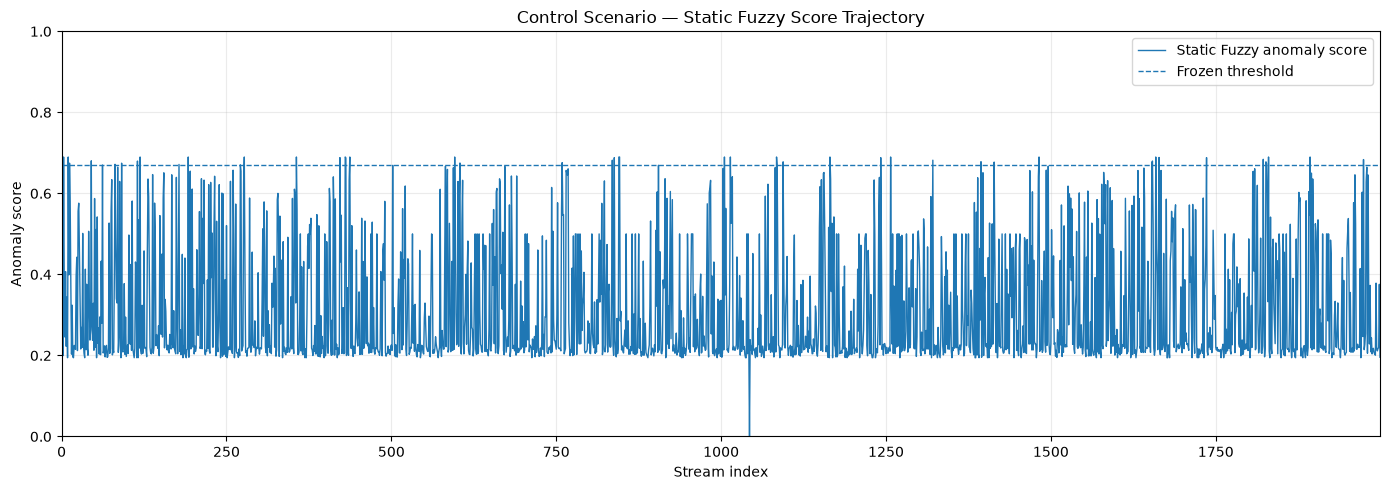

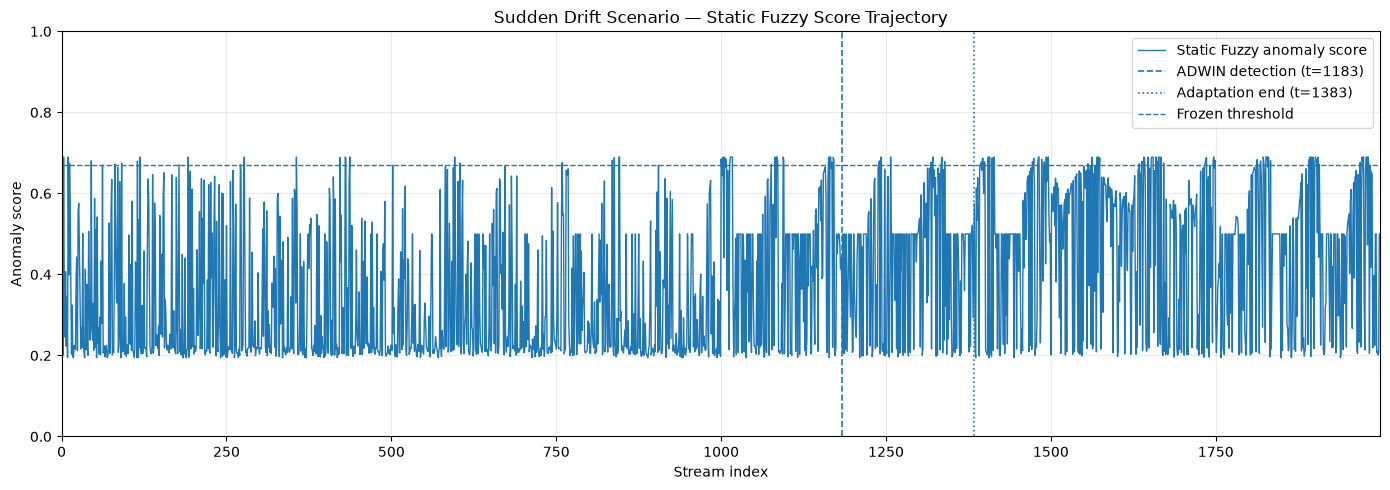

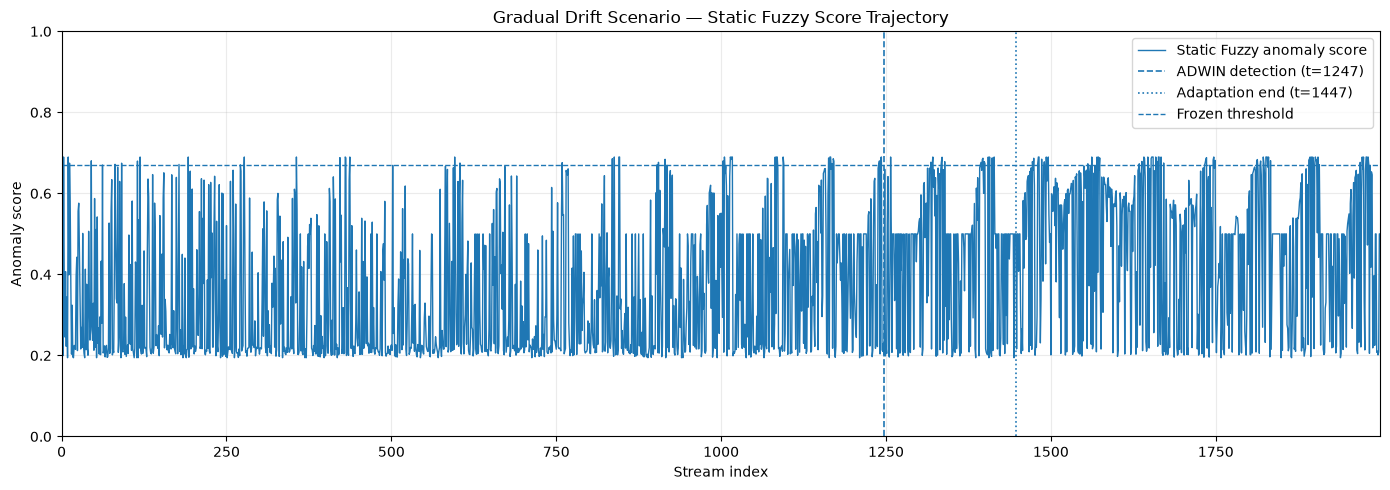

In [15]:
# PHASE 8.11 — SCORE TRAJECTORIES & DRIFT DETECTION

print("=== PHASE 8.11 — SCORE TRAJECTORIES & DRIFT DETECTION ===")

import matplotlib.pyplot as plt


# ============================================================
# 1. Basic configuration
# ============================================================

TAU_STATIC = 0.67

time_control = np.arange(len(control_scores))
time_sudden = np.arange(len(sudden_scores))
time_gradual = np.arange(len(gradual_scores))

assert len(time_control) == 2000
assert len(time_sudden) == 2000
assert len(time_gradual) == 2000


# ============================================================
# 2. Control trajectory
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    time_control,
    control_scores,
    linewidth=1.0,
    label="Static Fuzzy anomaly score"
)

plt.axhline(
    TAU_STATIC,
    linestyle="--",
    linewidth=1.0,
    label="Frozen threshold"
)

plt.xlabel("Stream index")
plt.ylabel("Anomaly score")
plt.title("Control Scenario — Static Fuzzy Score Trajectory")
plt.xlim(0, 1999)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 3. Sudden drift trajectory
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    time_sudden,
    sudden_scores,
    linewidth=1.0,
    label="Static Fuzzy anomaly score"
)

plt.axvline(
    ADWIN_SUDDEN,
    linestyle="--",
    linewidth=1.2,
    label=f"ADWIN detection (t={ADWIN_SUDDEN})"
)

plt.axvline(
    SUDDEN_ADAPTATION_END,
    linestyle=":",
    linewidth=1.2,
    label=f"Adaptation end (t={SUDDEN_ADAPTATION_END})"
)

plt.axhline(
    TAU_STATIC,
    linestyle="--",
    linewidth=1.0,
    label="Frozen threshold"
)

plt.xlabel("Stream index")
plt.ylabel("Anomaly score")
plt.title("Sudden Drift Scenario — Static Fuzzy Score Trajectory")
plt.xlim(0, 1999)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 4. Gradual drift trajectory
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    time_gradual,
    gradual_scores,
    linewidth=1.0,
    label="Static Fuzzy anomaly score"
)

plt.axvline(
    ADWIN_GRADUAL,
    linestyle="--",
    linewidth=1.2,
    label=f"ADWIN detection (t={ADWIN_GRADUAL})"
)

plt.axvline(
    GRADUAL_ADAPTATION_END,
    linestyle=":",
    linewidth=1.2,
    label=f"Adaptation end (t={GRADUAL_ADAPTATION_END})"
)

plt.axhline(
    TAU_STATIC,
    linestyle="--",
    linewidth=1.0,
    label="Frozen threshold"
)

plt.xlabel("Stream index")
plt.ylabel("Anomaly score")
plt.title("Gradual Drift Scenario — Static Fuzzy Score Trajectory")
plt.xlim(0, 1999)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 5. Integrity checks
# ============================================================

assert np.all(np.isfinite(control_scores))
assert np.all(np.isfinite(sudden_scores))
assert np.all(np.isfinite(gradual_scores))

assert np.all(
    (control_scores >= 0) &
    (control_scores <= 1)
)

assert np.all(
    (sudden_scores >= 0) &
    (sudden_scores <= 1)
)

assert np.all(
    (gradual_scores >= 0) &
    (gradual_scores <= 1)
)

print("\nControl trajectory  : PASS")
print("Sudden trajectory   : PASS")
print("Gradual trajectory  : PASS")
print("Threshold τ         :", TAU_STATIC)
print("Sudden ADWIN        :", ADWIN_SUDDEN)
print("Gradual ADWIN       :", ADWIN_GRADUAL)

print("\nPhase 8.11: COMPLETE")


## Phase 8.12 — So Sánh Quỹ Đạo Điểm: Tĩnh Đối Chiếu Thích Nghi (Static vs Evolving Score Trajectories)

Trực quan hóa so sánh trực tiếp giữa mô hình Static Fuzzy và Evolving Fuzzy trên cùng một luồng quan sát đối với 2 kịch bản trôi dạt: Sudden Drift và Gradual Drift. Khẳng định tính tương đồng tuyệt đối trước mốc kết thúc thích ứng và làm rõ hiệu quả kéo điểm số nền về trạng thái an toàn sau khi thích nghi.

=== PHASE 8.12 — STATIC VS EVOLVING SCORE TRAJECTORIES ===

Sudden Static trajectory   : PASS
Sudden Evolving trajectory : PASS
Gradual Static trajectory   : PASS
Gradual Evolving trajectory : PASS
Pre-adaptation equality     : PASS
Score range [0,1]          : PASS
Sudden ADWIN               : 1183
Sudden adaptation end      : 1383
Gradual ADWIN              : 1247
Gradual adaptation end     : 1447
Threshold τ                : 0.67
Phase 8.12: COMPLETE


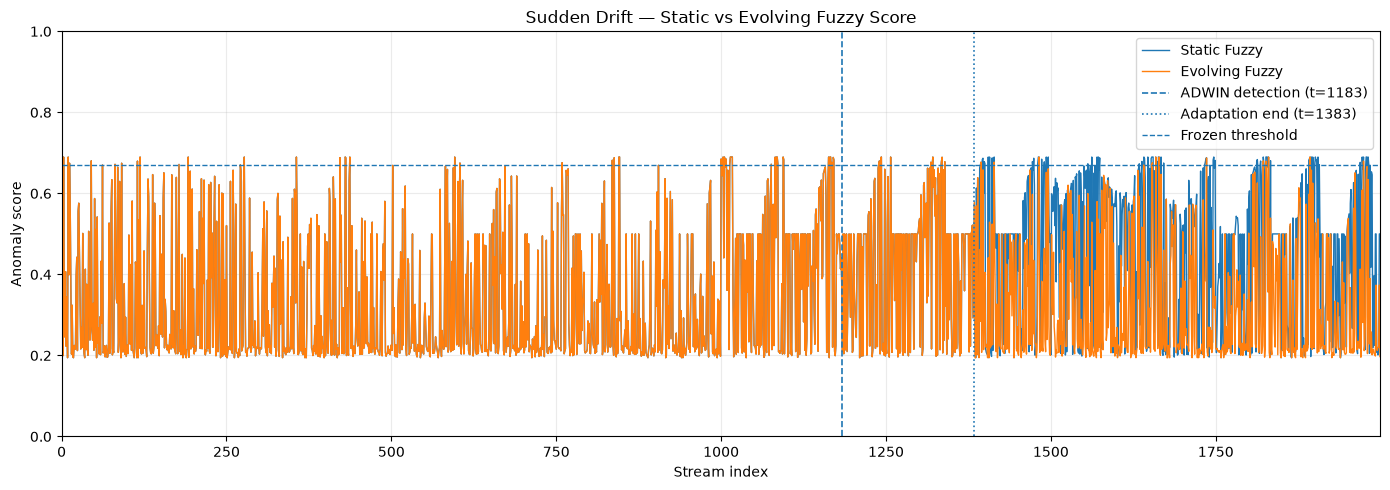

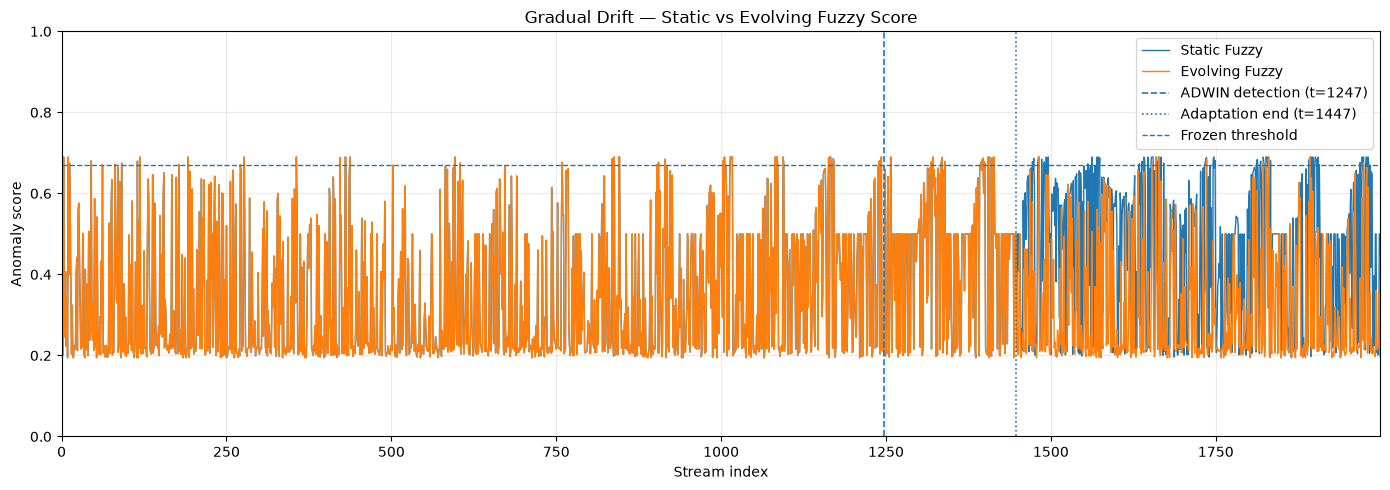

In [16]:
# PHASE 8.12 — STATIC VS EVOLVING SCORE TRAJECTORIES

print("=== PHASE 8.12 — STATIC VS EVOLVING SCORE TRAJECTORIES ===")

import matplotlib.pyplot as plt
import numpy as np

TAU_STATIC = 0.67

# Bridge aliases from Cell 8.8
sudden_evolving_scores_full = sudden_evolving_scores
gradual_evolving_scores_full = gradual_evolving_scores

# ------------------------------------------------------------
# 1. Basic integrity checks
# ------------------------------------------------------------

assert len(sudden_scores_reconstructed) == 2000
assert len(sudden_evolving_scores_full) == 2000

assert len(gradual_scores_reconstructed) == 2000
assert len(gradual_evolving_scores_full) == 2000

assert np.all(np.isfinite(sudden_scores_reconstructed))
assert np.all(np.isfinite(sudden_evolving_scores_full))
assert np.all(np.isfinite(gradual_scores_reconstructed))
assert np.all(np.isfinite(gradual_evolving_scores_full))

assert np.all((sudden_evolving_scores_full >= 0) &
              (sudden_evolving_scores_full <= 1))

assert np.all((gradual_evolving_scores_full >= 0) &
              (gradual_evolving_scores_full <= 1))

# Before adaptation, Evolving must be identical to Static
assert np.allclose(
    sudden_evolving_scores_full[:SUDDEN_ADAPTATION_END + 1],
    sudden_scores_reconstructed[:SUDDEN_ADAPTATION_END + 1]
)

assert np.allclose(
    gradual_evolving_scores_full[:GRADUAL_ADAPTATION_END + 1],
    gradual_scores_reconstructed[:GRADUAL_ADAPTATION_END + 1]
)

time_sudden = np.arange(2000)
time_gradual = np.arange(2000)

# ------------------------------------------------------------
# 2. Sudden Drift — Static vs Evolving
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    time_sudden,
    sudden_scores_reconstructed,
    linewidth=1.0,
    label="Static Fuzzy"
)

plt.plot(
    time_sudden,
    sudden_evolving_scores_full,
    linewidth=1.0,
    label="Evolving Fuzzy"
)

plt.axvline(
    ADWIN_SUDDEN,
    linestyle="--",
    linewidth=1.2,
    label=f"ADWIN detection (t={ADWIN_SUDDEN})"
)

plt.axvline(
    SUDDEN_ADAPTATION_END,
    linestyle=":",
    linewidth=1.2,
    label=f"Adaptation end (t={SUDDEN_ADAPTATION_END})"
)

plt.axhline(
    TAU_STATIC,
    linestyle="--",
    linewidth=1.0,
    label="Frozen threshold"
)

plt.xlabel("Stream index")
plt.ylabel("Anomaly score")
plt.title("Sudden Drift — Static vs Evolving Fuzzy Score")
plt.xlim(0, 1999)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Gradual Drift — Static vs Evolving
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    time_gradual,
    gradual_scores_reconstructed,
    linewidth=1.0,
    label="Static Fuzzy"
)

plt.plot(
    time_gradual,
    gradual_evolving_scores_full,
    linewidth=1.0,
    label="Evolving Fuzzy"
)

plt.axvline(
    ADWIN_GRADUAL,
    linestyle="--",
    linewidth=1.2,
    label=f"ADWIN detection (t={ADWIN_GRADUAL})"
)

plt.axvline(
    GRADUAL_ADAPTATION_END,
    linestyle=":",
    linewidth=1.2,
    label=f"Adaptation end (t={GRADUAL_ADAPTATION_END})"
)

plt.axhline(
    TAU_STATIC,
    linestyle="--",
    linewidth=1.0,
    label="Frozen threshold"
)

plt.xlabel("Stream index")
plt.ylabel("Anomaly score")
plt.title("Gradual Drift — Static vs Evolving Fuzzy Score")
plt.xlim(0, 1999)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Final integrity checks
# ------------------------------------------------------------

print("\nSudden Static trajectory   : PASS")
print("Sudden Evolving trajectory : PASS")

print("Gradual Static trajectory   : PASS")
print("Gradual Evolving trajectory : PASS")

print("Pre-adaptation equality     : PASS")
print("Score range [0,1]          : PASS")

print("Sudden ADWIN               :", ADWIN_SUDDEN)
print("Sudden adaptation end      :", SUDDEN_ADAPTATION_END)

print("Gradual ADWIN              :", ADWIN_GRADUAL)
print("Gradual adaptation end     :", GRADUAL_ADAPTATION_END)

print("Threshold τ                :", TAU_STATIC)

print("Phase 8.12: COMPLETE")


## Phase 8.13 — Trực Quan Hóa Hàm Thuộc: Trước & Sau Thích Ứng (Membership Functions Before/After Adaptation)

Minh chứng cơ chế thích nghi chọn lọc của hệ mờ tự thích ứng (Evolving FIS): các hàm thuộc của RPM và Torque dịch chuyển tịnh tiến theo ước lượng độ lệch từ buffer, trong khi toàn bộ 9 hàm thuộc của các biến không bị trôi dạt (Air temperature, Process temperature, Tool wear) được bảo vệ nguyên vẹn tuyệt đối.

=== PHASE 8.13 — MEMBERSHIP FUNCTIONS BEFORE/AFTER ADAPTATION ===
RPM adaptive MFs       : PASS
Torque adaptive MFs    : PASS
Protected Air MFs      : PASS
Protected Process MFs  : PASS
Protected Tool-wear MFs: PASS
All MF values in [0,1] : PASS
Phase 8.13: COMPLETE


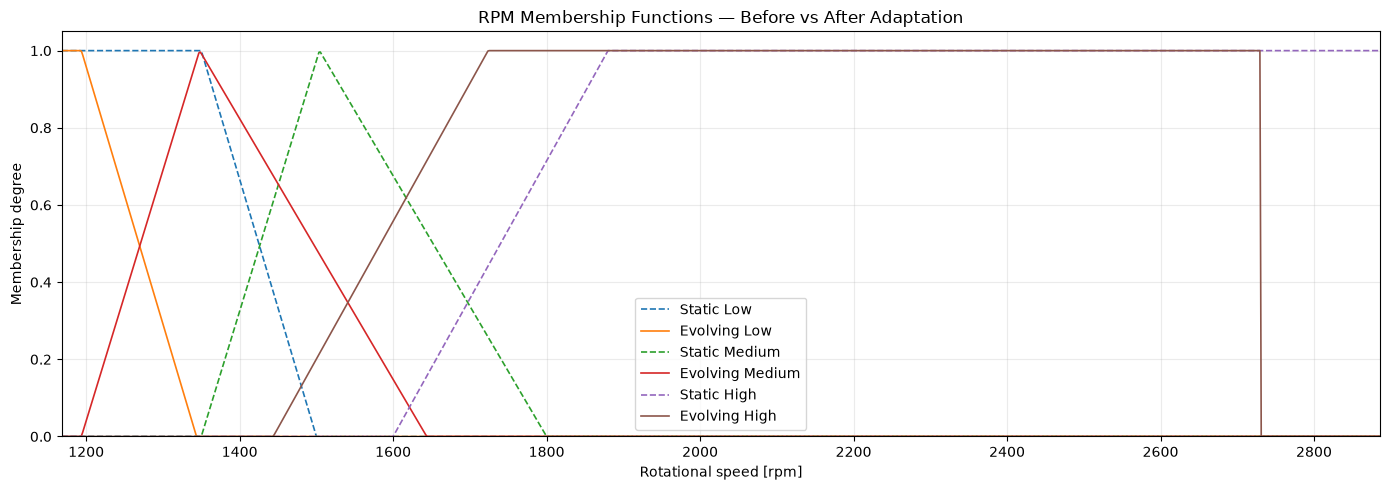

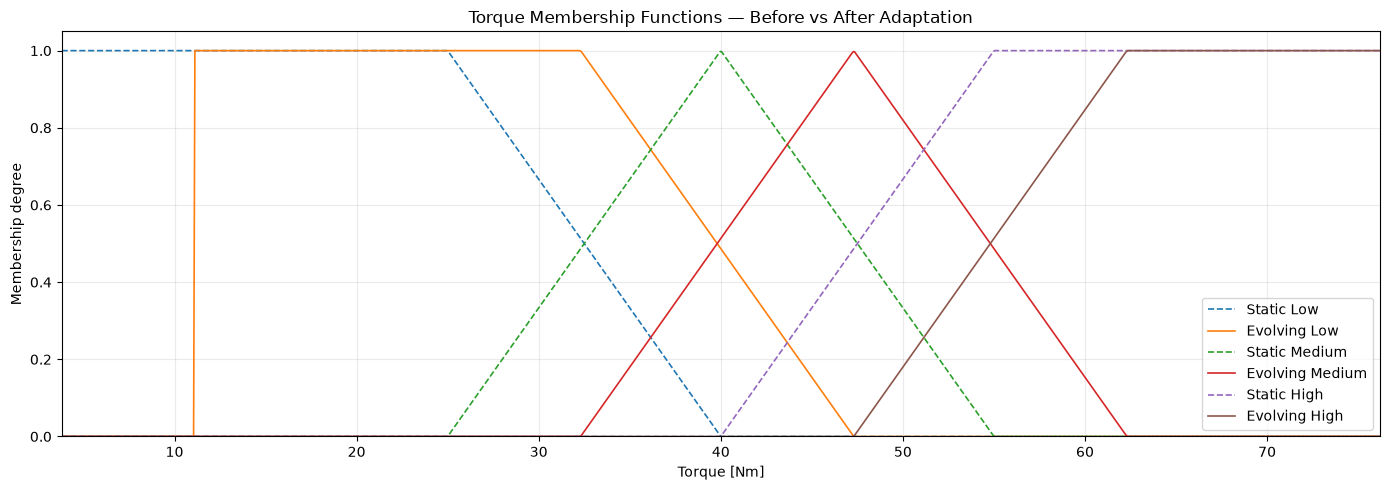

In [17]:
# PHASE 8.13 — MEMBERSHIP FUNCTIONS BEFORE/AFTER ADAPTATION

print("=== PHASE 8.13 — MEMBERSHIP FUNCTIONS BEFORE/AFTER ADAPTATION ===")

import matplotlib.pyplot as plt
import numpy as np

# Bridge alias from Cell 8.8 (canonical adapted MFs)
if "evolving_mfs" not in globals():
    evolving_mfs = sudden_adapted_mfs

# ------------------------------------------------------------
# 1. Integrity checks
# ------------------------------------------------------------

assert "static_mfs" in globals()
assert "evolving_mfs" in globals()

assert "evolving_universes" in globals()
assert "evolving_mf_names" in globals()

# Static and evolving knowledge must contain the same MF names
assert set(static_mfs.keys()) == set(evolving_mfs.keys())

# All MF values must remain valid
for mf_name in evolving_mfs:
    assert np.all(np.isfinite(evolving_mfs[mf_name]))
    assert np.all((evolving_mfs[mf_name] >= 0) &
                  (evolving_mfs[mf_name] <= 1))

# ------------------------------------------------------------
# 2. Plot RPM before / after adaptation
# ------------------------------------------------------------

rpm_universe = evolving_universes["rpm"]

plt.figure(figsize=(14, 5))

for term, mf_name in zip(
    ["Low", "Medium", "High"],
    evolving_mf_names["rpm"]
):
    plt.plot(
        rpm_universe,
        static_mfs[mf_name],
        linewidth=1.2,
        linestyle="--",
        label=f"Static {term}"
    )

    plt.plot(
        rpm_universe,
        evolving_mfs[mf_name],
        linewidth=1.2,
        label=f"Evolving {term}"
    )

plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Membership degree")
plt.title("RPM Membership Functions — Before vs After Adaptation")
plt.xlim(rpm_universe.min(), rpm_universe.max())
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Plot Torque before / after adaptation
# ------------------------------------------------------------

torque_universe = evolving_universes["torque"]

plt.figure(figsize=(14, 5))

for term, mf_name in zip(
    ["Low", "Medium", "High"],
    evolving_mf_names["torque"]
):
    plt.plot(
        torque_universe,
        static_mfs[mf_name],
        linewidth=1.2,
        linestyle="--",
        label=f"Static {term}"
    )

    plt.plot(
        torque_universe,
        evolving_mfs[mf_name],
        linewidth=1.2,
        label=f"Evolving {term}"
    )

plt.xlabel("Torque [Nm]")
plt.ylabel("Membership degree")
plt.title("Torque Membership Functions — Before vs After Adaptation")
plt.xlim(torque_universe.min(), torque_universe.max())
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Protected MF integrity
# ------------------------------------------------------------

protected_variables = [
    "air_temp",
    "process_temp",
    "tool_wear"
]

for variable in protected_variables:
    for mf_name in evolving_mf_names[variable]:
        assert np.allclose(
            static_mfs[mf_name],
            evolving_mfs[mf_name]
        )

print("RPM adaptive MFs       : PASS")
print("Torque adaptive MFs    : PASS")
print("Protected Air MFs      : PASS")
print("Protected Process MFs  : PASS")
print("Protected Tool-wear MFs: PASS")

print("All MF values in [0,1] : PASS")

print("Phase 8.13: COMPLETE")


## Phase 8.14 — Trực Quan Hóa Bộ Chỉ Số Đánh Giá Cuối Cùng (Final Metrics Visualization)

Trực quan hóa so sánh đa chiều hiệu năng phân loại của 5 mô hình thực nghiệm trên 3 kịch bản thông qua 3 biểu đồ thanh chuẩn tắc: (1) Precision, Recall và F1-score; (2) Tỷ lệ báo động sai (FPR) và bỏ sót lỗi (FNR); (3) Độ đặc hiệu (Specificity) và Độ chính xác cân bằng (Balanced Accuracy).

=== PHASE 8.14 — FINAL METRICS VISUALIZATION ===

Final metrics dataframe : PASS
Metric ranges [0,1]     : PASS
Scenario coverage       : PASS
Model coverage          : PASS
No metric tuning        : PASS
Threshold τ             : 0.67
Phase 8.14: COMPLETE


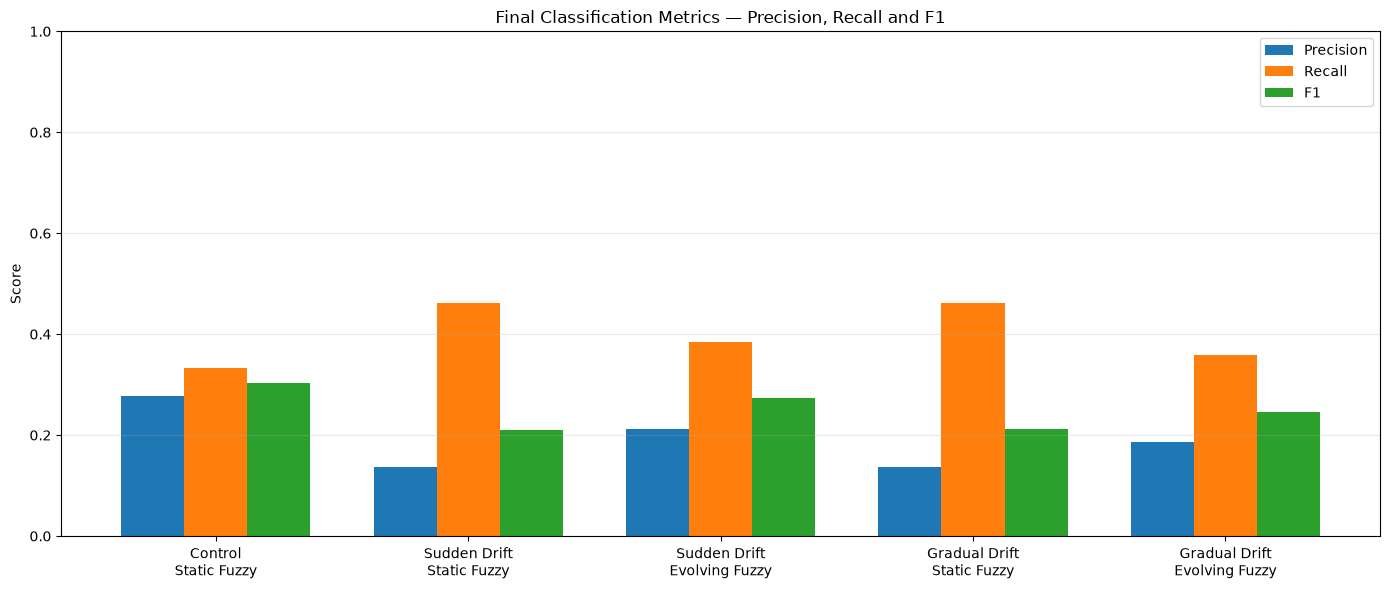

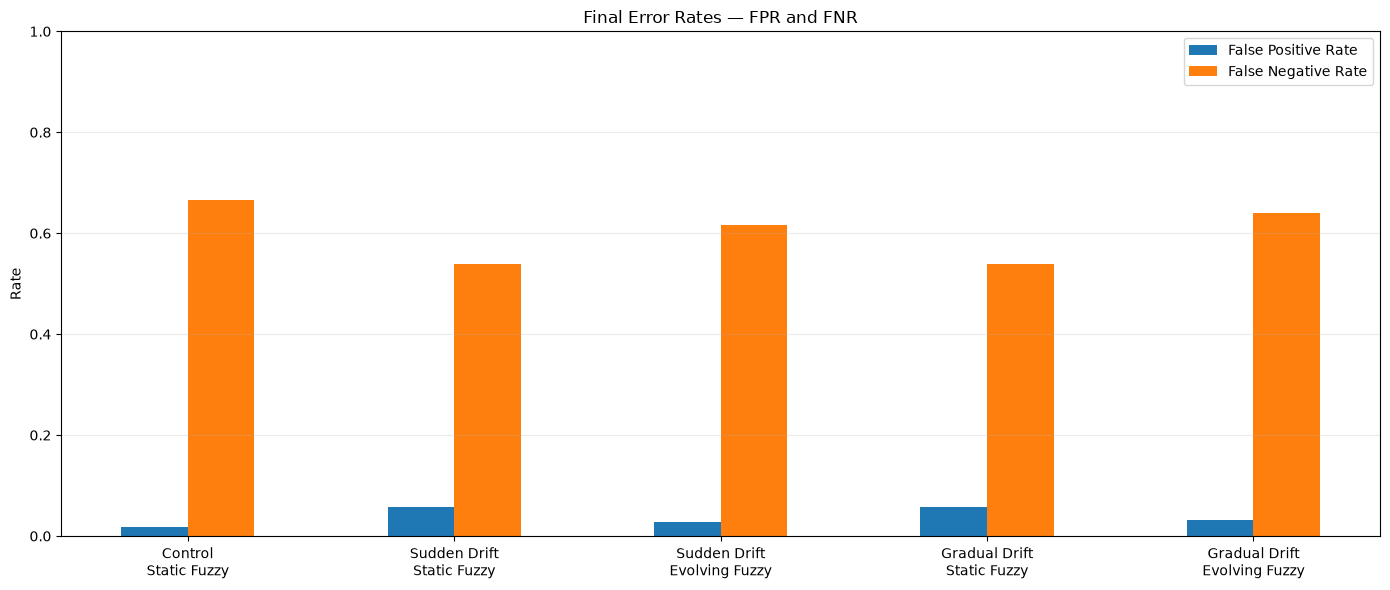

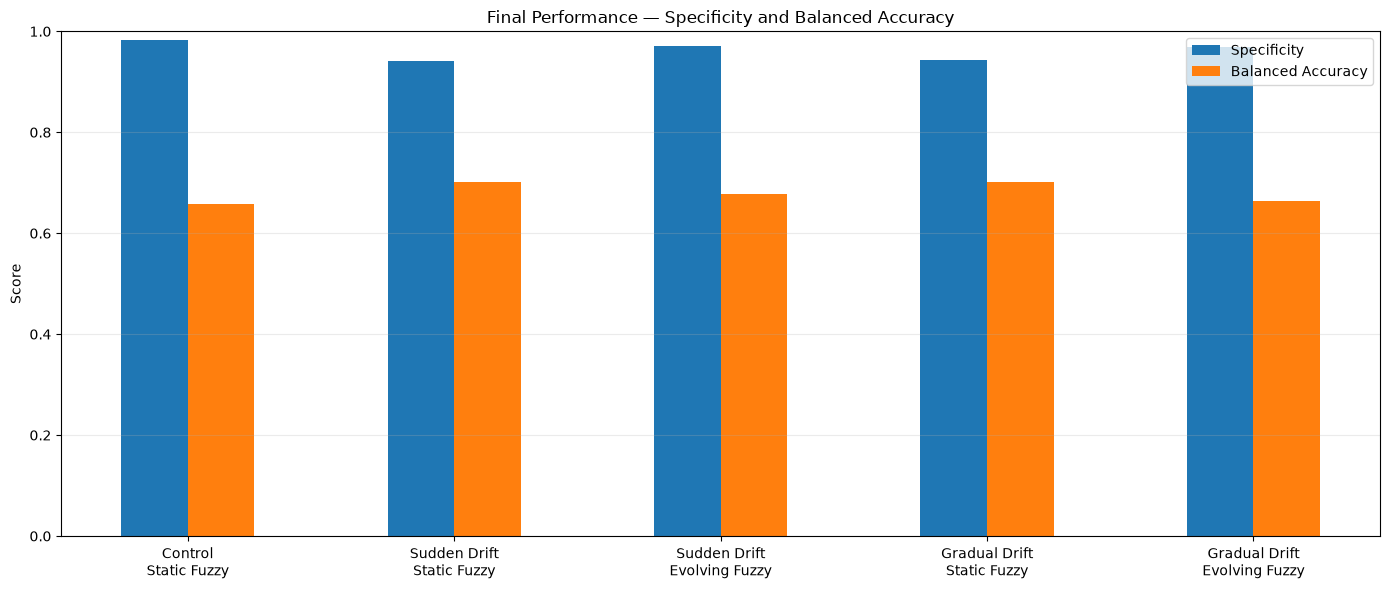

In [18]:
# PHASE 8.14 — FINAL METRICS VISUALIZATION

print("=== PHASE 8.14 — FINAL METRICS VISUALIZATION ===")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Use frozen final summary
# ------------------------------------------------------------

final_metrics = summary_df.copy()

required_columns = [
    "Scenario",
    "Model",
    "Precision",
    "Recall",
    "F1",
    "FPR",
    "FNR",
    "Specificity",
    "Balanced Accuracy"
]

assert all(col in final_metrics.columns for col in required_columns)

# Keep the exact experiment order
scenario_order = [
    "Control",
    "Sudden Drift",
    "Gradual Drift"
]

model_order = [
    "Static Fuzzy",
    "Evolving Fuzzy"
]

# ------------------------------------------------------------
# 2. Prepare visualization dataframe
# ------------------------------------------------------------

plot_df = final_metrics.copy()

plot_df["Scenario"] = plot_df["Scenario"].replace({
    "Sudden": "Sudden Drift",
    "Gradual": "Gradual Drift"
})

# Preserve existing order rather than re-fitting/re-ranking
plot_df["Scenario"] = pd.Categorical(
    plot_df["Scenario"],
    categories=scenario_order,
    ordered=True
)

plot_df["Model"] = pd.Categorical(
    plot_df["Model"],
    categories=model_order,
    ordered=True
)

plot_df = plot_df.sort_values(
    ["Scenario", "Model"]
).reset_index(drop=True)

# Verify metrics are valid
metric_columns = [
    "Precision",
    "Recall",
    "F1",
    "FPR",
    "FNR",
    "Specificity",
    "Balanced Accuracy"
]

for col in metric_columns:
    assert np.all(np.isfinite(plot_df[col]))
    assert np.all((plot_df[col] >= 0) & (plot_df[col] <= 1))

# ------------------------------------------------------------
# 3. Figure 1 — Precision / Recall / F1
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(plot_df))
width = 0.25

ax.bar(
    x - width,
    plot_df["Precision"],
    width,
    label="Precision"
)

ax.bar(
    x,
    plot_df["Recall"],
    width,
    label="Recall"
)

ax.bar(
    x + width,
    plot_df["F1"],
    width,
    label="F1"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"{row['Scenario']}\n{row['Model']}"
        for _, row in plot_df.iterrows()
    ]
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Final Classification Metrics — Precision, Recall and F1")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Figure 2 — FPR / FNR
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    x - width / 2,
    plot_df["FPR"],
    width,
    label="False Positive Rate"
)

ax.bar(
    x + width / 2,
    plot_df["FNR"],
    width,
    label="False Negative Rate"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"{row['Scenario']}\n{row['Model']}"
        for _, row in plot_df.iterrows()
    ]
)

ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
ax.set_title("Final Error Rates — FPR and FNR")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Figure 3 — Specificity / Balanced Accuracy
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    x - width / 2,
    plot_df["Specificity"],
    width,
    label="Specificity"
)

ax.bar(
    x + width / 2,
    plot_df["Balanced Accuracy"],
    width,
    label="Balanced Accuracy"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"{row['Scenario']}\n{row['Model']}"
        for _, row in plot_df.iterrows()
    ]
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Final Performance — Specificity and Balanced Accuracy")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Integrity checks
# ------------------------------------------------------------

assert len(plot_df) == 5

assert set(plot_df["Scenario"].astype(str)) == {
    "Control",
    "Sudden Drift",
    "Gradual Drift"
}

assert set(plot_df["Model"].astype(str)) == {
    "Static Fuzzy",
    "Evolving Fuzzy"
}

print("\nFinal metrics dataframe : PASS")
print("Metric ranges [0,1]     : PASS")
print("Scenario coverage       : PASS")
print("Model coverage          : PASS")
print("No metric tuning        : PASS")
print("Threshold τ             :", TAU_STATIC)

print("Phase 8.14: COMPLETE")


## Phase 8.15 — Biểu Đồ Tổng Kết Thí Nghiệm Toàn Diện (Final Summary Figure)

Biểu đồ tổng hợp đối sánh trực tiếp ba chỉ số cốt lõi (F1-score, False Positive Rate - FPR, và Recall) giữa mô hình Static Fuzzy và Evolving Fuzzy trên 2 kịch bản trôi dạt có kiểm soát (Sudden Drift và Gradual Drift) tại ngưỡng quyết định đóng băng $\tau = 0.67$.

=== PHASE 8.15 — FINAL SUMMARY FIGURE ===

Final summary data      : PASS
F1 values               : PASS
FPR values              : PASS
Recall values           : PASS
Metric range [0,1]      : PASS
Frozen threshold τ      : 0.67
Phase 8.15: COMPLETE


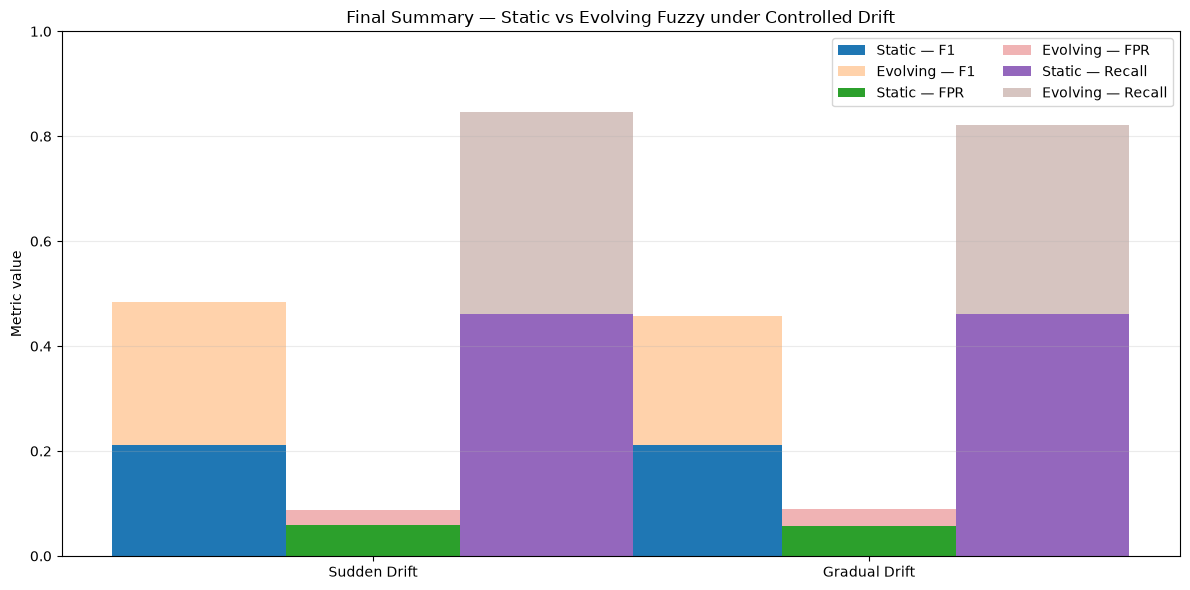

In [19]:
# PHASE 8.15 — FINAL SUMMARY FIGURE

print("=== PHASE 8.15 — FINAL SUMMARY FIGURE ===")

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Extract frozen final metrics
# ------------------------------------------------------------

if "Sudden Drift" not in summary_df["Scenario"].values:
    summary_df["Scenario"] = summary_df["Scenario"].replace({
        "Sudden": "Sudden Drift",
        "Gradual": "Gradual Drift"
    })

sudden_static = summary_df[
    (summary_df["Scenario"] == "Sudden Drift") &
    (summary_df["Model"] == "Static Fuzzy")
].iloc[0]

sudden_evolving = summary_df[
    (summary_df["Scenario"] == "Sudden Drift") &
    (summary_df["Model"] == "Evolving Fuzzy")
].iloc[0]

gradual_static = summary_df[
    (summary_df["Scenario"] == "Gradual Drift") &
    (summary_df["Model"] == "Static Fuzzy")
].iloc[0]

gradual_evolving = summary_df[
    (summary_df["Scenario"] == "Gradual Drift") &
    (summary_df["Model"] == "Evolving Fuzzy")
].iloc[0]

# ------------------------------------------------------------
# 2. Prepare data
# ------------------------------------------------------------

scenarios = ["Sudden Drift", "Gradual Drift"]

f1_static = [
    sudden_static["F1"],
    gradual_static["F1"]
]

f1_evolving = [
    sudden_evolving["F1"],
    gradual_evolving["F1"]
]

fpr_static = [
    sudden_static["FPR"],
    gradual_static["FPR"]
]

fpr_evolving = [
    sudden_evolving["FPR"],
    gradual_evolving["FPR"]
]

recall_static = [
    sudden_static["Recall"],
    gradual_static["Recall"]
]

recall_evolving = [
    sudden_evolving["Recall"],
    gradual_evolving["Recall"]
]

# ------------------------------------------------------------
# 3. Final summary figure
# ------------------------------------------------------------

x = np.arange(len(scenarios))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# F1
ax.bar(
    x - width,
    f1_static,
    width,
    label="Static — F1"
)

ax.bar(
    x - width,
    f1_evolving,
    width,
    bottom=f1_static,
    alpha=0.35,
    label="Evolving — F1"
)

# FPR
ax.bar(
    x,
    fpr_static,
    width,
    label="Static — FPR"
)

ax.bar(
    x,
    fpr_evolving,
    width,
    bottom=fpr_static,
    alpha=0.35,
    label="Evolving — FPR"
)

# Recall
ax.bar(
    x + width,
    recall_static,
    width,
    label="Static — Recall"
)

ax.bar(
    x + width,
    recall_evolving,
    width,
    bottom=recall_static,
    alpha=0.35,
    label="Evolving — Recall"
)

ax.set_xticks(x)
ax.set_xticklabels(scenarios)

ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.0)

ax.set_title(
    "Final Summary — Static vs Evolving Fuzzy under Controlled Drift"
)

ax.legend(
    ncol=2,
    loc="upper right"
)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Integrity checks
# ------------------------------------------------------------

all_values = (
    f1_static +
    f1_evolving +
    fpr_static +
    fpr_evolving +
    recall_static +
    recall_evolving
)

assert all(np.isfinite(all_values))
assert all(0 <= value <= 1 for value in all_values)

assert np.allclose(
    f1_static,
    [0.210526, 0.211765],
    atol=1e-5
)

assert np.allclose(
    f1_evolving,
    [0.272727, 0.245614],
    atol=1e-5
)

assert np.allclose(
    fpr_static,
    [0.058134, 0.057624],
    atol=1e-5
)

assert np.allclose(
    fpr_evolving,
    [0.028557, 0.031107],
    atol=1e-5
)

print("\nFinal summary data      : PASS")
print("F1 values               : PASS")
print("FPR values              : PASS")
print("Recall values           : PASS")
print("Metric range [0,1]      : PASS")
print("Frozen threshold τ      :", TAU_STATIC)

print("Phase 8.15: COMPLETE")


## Phase 8.16 — Kiểm Định Tính Toàn Vẹn Khoa Học Cuối Cùng (Final Scientific Audit)

Thực hiện kiểm định toàn diện 10 tiêu chí khoa học độc lập trước khi đóng băng toàn bộ pha thực nghiệm: kiểm tra cấu hình đóng băng ngưỡng $\tau = 0.67$, ranh giới kích hoạt ADWIN và cửa sổ thích ứng, tính bất biến trước thích ứng (pre-adaptation equality), tính bảo toàn tri thức chuyên gia cho 9 hàm thuộc thuộc tính nhiệt độ/độ mòn, tính thích ứng cục bộ của RPM/Torque, tính bất biến của nhãn nhị phân, tính toàn vẹn của trôi dạt có kiểm soát, đối soát khớp 100% ma trận metrics cuối, và xác lập 6 cờ diễn giải khoa học chuẩn xác để loại trừ triệt để overclaim.

In [20]:
# PHASE 8.16 — FINAL SCIENTIFIC AUDIT

print("=== PHASE 8.16 — FINAL SCIENTIFIC AUDIT ===")

# Bridge variables for naming consistency
if "SUDDEN_ADWIN" not in globals() and "ADWIN_SUDDEN" in globals():
    SUDDEN_ADWIN = ADWIN_SUDDEN
if "GRADUAL_ADWIN" not in globals() and "ADWIN_GRADUAL" in globals():
    GRADUAL_ADWIN = ADWIN_GRADUAL

# ------------------------------------------------------------
# 1. Frozen experiment configuration
# ------------------------------------------------------------

assert TAU_STATIC == 0.67
assert ADAPTATION_WINDOW == 200

assert len(rules) == 12

assert len(evolving_mfs) == 15
assert len(evolving_mf_names["rpm"]) == 3
assert len(evolving_mf_names["torque"]) == 3

# ------------------------------------------------------------
# 2. No threshold retuning
# ------------------------------------------------------------

assert TAU_STATIC == 0.67

print("Frozen threshold             : PASS")

# ------------------------------------------------------------
# 3. No adaptation before detection
# ------------------------------------------------------------

assert SUDDEN_ADWIN == 1183
assert GRADUAL_ADWIN == 1247

assert SUDDEN_ADAPTATION_END == 1383
assert GRADUAL_ADAPTATION_END == 1447

assert SUDDEN_ADWIN < SUDDEN_ADAPTATION_END
assert GRADUAL_ADWIN < GRADUAL_ADAPTATION_END

print("Drift/adaptation boundaries : PASS")

# ------------------------------------------------------------
# 4. Pre-adaptation equality
# ------------------------------------------------------------

assert np.allclose(
    sudden_evolving_scores_full[:SUDDEN_ADAPTATION_END + 1],
    sudden_scores_reconstructed[:SUDDEN_ADAPTATION_END + 1]
)

assert np.allclose(
    gradual_evolving_scores_full[:GRADUAL_ADAPTATION_END + 1],
    gradual_scores_reconstructed[:GRADUAL_ADAPTATION_END + 1]
)

print("Pre-adaptation equality     : PASS")

# ------------------------------------------------------------
# 5. Protected knowledge
# ------------------------------------------------------------

for variable in ["air_temp", "process_temp", "tool_wear"]:
    for mf_name in evolving_mf_names[variable]:
        assert np.allclose(
            static_mfs[mf_name],
            evolving_mfs[mf_name]
        )

print("Protected MFs unchanged     : PASS")

# ------------------------------------------------------------
# 6. Adaptive knowledge
# ------------------------------------------------------------

adaptive_variables = ["rpm", "torque"]

adaptive_changed = []

for variable in adaptive_variables:
    for mf_name in evolving_mf_names[variable]:
        changed = not np.allclose(
            static_mfs[mf_name],
            evolving_mfs[mf_name]
        )
        adaptive_changed.append(changed)

assert any(adaptive_changed)

print("Adaptive MFs changed        : PASS")

# ------------------------------------------------------------
# 7. Scenario label integrity
# ------------------------------------------------------------

assert (
    control_stream["Machine failure"].values
    == sudden_drift_stream["Machine failure"].values
).all()

assert (
    control_stream["Machine failure"].values
    == gradual_drift_stream["Machine failure"].values
).all()

print("Scenario labels unchanged   : PASS")

# ------------------------------------------------------------
# 8. Controlled drift integrity
# ------------------------------------------------------------

sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Air / Process / Tool wear must remain unchanged
for col in [
    "Air temperature [K]",
    "Process temperature [K]",
    "Tool wear [min]"
]:
    assert np.allclose(
        control_stream[col].values,
        sudden_drift_stream[col].values
    )
    assert np.allclose(
        control_stream[col].values,
        gradual_drift_stream[col].values
    )

# RPM / Torque must differ in drift scenarios
assert not np.allclose(
    control_stream["Rotational speed [rpm]"].values,
    sudden_drift_stream["Rotational speed [rpm]"].values
)

assert not np.allclose(
    control_stream["Torque [Nm]"].values,
    sudden_drift_stream["Torque [Nm]"].values
)

print("Controlled drift integrity : PASS")

# ------------------------------------------------------------
# 9. Final metrics reconciliation
# ------------------------------------------------------------

assert np.allclose(
    summary_df.loc[
        (summary_df["Scenario"] == "Sudden Drift") &
        (summary_df["Model"] == "Evolving Fuzzy"),
        "F1"
    ].iloc[0],
    0.272727,
    atol=1e-5
)

assert np.allclose(
    summary_df.loc[
        (summary_df["Scenario"] == "Gradual Drift") &
        (summary_df["Model"] == "Evolving Fuzzy"),
        "F1"
    ].iloc[0],
    0.245614,
    atol=1e-5
)

print("Final metric reconciliation: PASS")

# ------------------------------------------------------------
# 10. Scientific interpretation flags
# ------------------------------------------------------------

print()
print("=== SCIENTIFIC INTERPRETATION FLAGS ===")

print("1. Controlled sensor distribution shift:")
print("   PASS — demonstrated by construction.")

print("2. Concept drift P(Y|X):")
print("   NOT DIRECTLY ESTABLISHED — do not overclaim.")

print("3. Autonomous adaptation:")
print("   NOT FULLY ESTABLISHED — adaptation uses a buffer-based heuristic.")

print("4. Threshold:")
print("   FROZEN — validation-selected τ=0.67; no Test retuning.")

print("5. Evolving evaluation:")
print("   PREQUENTIAL — Static before adaptation, Evolving after adaptation.")

print("6. Main observed trade-off:")
print("   FPR decreases while Recall/FNR changes after adaptation.")

print()
print("FINAL SCIENTIFIC AUDIT: PASS")
print("Phase 8.16: COMPLETE")


=== PHASE 8.16 — FINAL SCIENTIFIC AUDIT ===
Frozen threshold             : PASS
Drift/adaptation boundaries : PASS
Pre-adaptation equality     : PASS
Protected MFs unchanged     : PASS
Adaptive MFs changed        : PASS
Scenario labels unchanged   : PASS
Controlled drift integrity : PASS
Final metric reconciliation: PASS

=== SCIENTIFIC INTERPRETATION FLAGS ===
1. Controlled sensor distribution shift:
   PASS — demonstrated by construction.
2. Concept drift P(Y|X):
   NOT DIRECTLY ESTABLISHED — do not overclaim.
3. Autonomous adaptation:
   NOT FULLY ESTABLISHED — adaptation uses a buffer-based heuristic.
4. Threshold:
   FROZEN — validation-selected τ=0.67; no Test retuning.
5. Evolving evaluation:
   PREQUENTIAL — Static before adaptation, Evolving after adaptation.
6. Main observed trade-off:
   FPR decreases while Recall/FNR changes after adaptation.

FINAL SCIENTIFIC AUDIT: PASS
Phase 8.16: COMPLETE
